# 🏥 IUI Prediction - Model Training & XAI (ข้อมูลทั้งหมด)

In [32]:
import sys
print(sys.executable)

# ติดตั้ง lightgbm ให้ถูก interpreter ที่ notebook ใช้จริง
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "lightgbm"], check=True)

import os
if os.getcwd().endswith("src"):
    os.chdir("..")

import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN

import shap

warnings.filterwarnings("ignore")


def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_")
        for col in df.columns
    ]
    return df


def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thresholds = np.clip(thresholds, 0, 1)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])


def calculate_net_benefit(y_true, y_prob, threshold):
    if threshold <= 0 or threshold >= 1:
        return np.nan

    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    threshold,
    outdir="reports_ours/figures/confusion_matrices"
):
    os.makedirs(outdir, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Preg (0)", "Preg (1)"],
        yticklabels=["Non-Preg (0)", "Preg (1)"]
    )
    plt.title(f"Confusion Matrix\n{model_name}\n(Threshold: {threshold:.3f})")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_CM.png")
    plt.close()


def plot_roc_curve(
    y_true,
    y_prob,
    model_name,
    auc_score,
    best_threshold,
    outdir="reports_ours/figures/roc_curves"
):
    os.makedirs(outdir, exist_ok=True)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thresholds = np.clip(thresholds, 0, 1)

    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve (area = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
    plt.scatter(
        [best_fpr],
        [best_tpr],
        marker="o",
        s=100,
        label=f"Optimal Threshold ({best_threshold:.2f})",
        zorder=5
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_ROC.png")
    plt.close()


print("✅ SETUP OK")

c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
✅ SETUP OK


### 2. โหลดและเตรียมข้อมูล (Standard - ข้อมูลทั้งหมด)

In [33]:
# ==========================================
# Block 2: Load data, group split, and impute
# ==========================================

df = pd.read_csv('data/processed/cycle_level_features.csv')
df = clean_column_names(df)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# กัน Date หลุดเข้าโมเดลหลัก
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

# target ต้องมีและเป็น numeric
if 'Result' not in df.columns:
    raise ValueError("Target column 'Result' not found.")

df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])

valid_target = {0, 1, 0.0, 1.0}
bad_target_vals = sorted(set(df['Result'].dropna().unique()) - valid_target)
if bad_target_vals:
    raise ValueError(f"Unexpected values in Result: {bad_target_vals}")

df['Result'] = df['Result'].astype(int)

# object columns อื่นให้พยายามแปลงเป็น numeric
object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())

# ต้องมี HN สำหรับ group split
if 'HN' not in df.columns:
    raise ValueError("Column 'HN' is required for group split.")

df = df.dropna(subset=['HN'])
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

# แยก X / y / groups
X_full = df.drop(columns=['Result'], errors='ignore')
y_full = df['Result'].copy()
groups = df['HN']

# group split by patient ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y_full.iloc[train_idx].copy()
y_test  = y_full.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test  = groups.iloc[test_idx].copy()

# เก็บข้อมูลอ้างอิงสำหรับ downstream analyses
keep_cols = [c for c in ['HN', 'Cycle_Number'] if c in X_test.columns]
test_info = X_test[keep_cols].copy() if keep_cols else pd.DataFrame(index=X_test.index)

# impute หลัง split เท่านั้น
cols_to_impute = [c for c in X_train.columns if c != 'HN']

# drop all-NaN cols ออกจากทั้ง X_train และ X_test
all_nan_cols = [c for c in cols_to_impute if X_train[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns in train:", all_nan_cols)
    X_train = X_train.drop(columns=all_nan_cols, errors='ignore')
    X_test  = X_test.drop(columns=all_nan_cols, errors='ignore')

cols_to_impute = [c for c in X_train.columns if c != 'HN']

imputer = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer.fit_transform(X_train[cols_to_impute]),
    columns=cols_to_impute,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    imputer.transform(X_test[cols_to_impute]),
    columns=cols_to_impute,
    index=X_test.index
)

# ใส่ HN กลับมาเพื่ออ้างอิงก่อนลบทิ้งจาก feature set
X_train_num['HN'] = X_train['HN'].values
X_test_num['HN']  = X_test['HN'].values

# เช็กว่าไม่มี patient leakage
train_hn = set(X_train_num['HN'])
test_hn  = set(X_test_num['HN'])
overlap  = train_hn.intersection(test_hn)
print("HN overlap train/test:", len(overlap))
assert len(overlap) == 0, "Patient leakage detected: overlapping HN in train/test"

X_train = X_train_num.copy()
X_test  = X_test_num.copy()

# ลบ HN ก่อนเข้าโมเดล
X_train = X_train.drop(columns=['HN'])
X_test  = X_test.drop(columns=['HN'])

# sanity check
for bad_col in ['Date', 'HN', 'Result']:
    assert bad_col not in X_train.columns, f'{bad_col} should not be in X_train'
    assert bad_col not in X_test.columns,  f'{bad_col} should not be in X_test'

suspicious_cols = [c for c in X_train.columns if 'result' in c.lower() or 'outcome' in c.lower()]
if suspicious_cols:
    raise ValueError(f"Potential leakage columns found: {suspicious_cols}")

# log event rate ของ full / train / test
print(f'\nEvent rate full:  {y_full.mean():.4f}')
print(f'Event rate train: {y_train.mean():.4f}')
print(f'Event rate test:  {y_test.mean():.4f}')

print(f'\nSplit done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f'จำนวนคอลัมน์ที่ใช้เทรน: {X_train.shape[1]} คอลัมน์')
print("Train positives:", int(y_train.sum()), "out of", len(y_train))
print("Test positives:",  int(y_test.sum()),  "out of", len(y_test))

Remaining object columns: ['HN']
HN overlap train/test: 0

Event rate full:  0.0621
Event rate train: 0.0605
Event rate test:  0.0687

Split done. Train: 2348, Test: 597
จำนวนคอลัมน์ที่ใช้เทรน: 63 คอลัมน์
Train positives: 142 out of 2348
Test positives: 41 out of 597


### 3. Hyperparameter Tuning & Model Selection

In [34]:
# ==========================================
# Block 3: Main Model Comparison (Test2 - LightGBM + wider param grid)
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from lightgbm import LGBMClassifier

results_list = []
trained_models = {}

os.makedirs('models_test2/saved_models', exist_ok=True)
os.makedirs('reports_test2/tables', exist_ok=True)

pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv = GroupKFold(n_splits=3)

# แยก n_iter ตาม param grid size
n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 8,
    'XGBoost': 20,       # เพิ่มจาก 12
    'CatBoost': 30,      # เพิ่มจาก 20
    'LightGBM': 20,      # ใหม่
    'MLP': 4
}

models_params = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                random_state=42,
                max_iter=2000
            ))
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        'params': {
            'n_estimators': [100, 200, 300],  # เพิ่ม 300
            'max_depth': [5, 10, 20, None],
            'min_samples_leaf': [1, 2, 5]     # เพิ่ม param ใหม่
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=pos_weight
        ),
        'params': {
            'n_estimators': [100, 200, 300],  # เพิ่ม 300
            'learning_rate': [0.005, 0.01, 0.05, 0.1],  # เพิ่ม 0.005
            'max_depth': [2, 3, 4, 5],
            'subsample': [0.8, 1.0],          # เพิ่ม param ใหม่
            'colsample_bytree': [0.8, 1.0]    # เพิ่ม param ใหม่
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(
            random_state=42,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'iterations': [100, 200, 300, 500],  # เพิ่ม 500
            'depth': [3, 4, 5, 6],
            'learning_rate': [0.005, 0.01, 0.05, 0.1],  # เพิ่ม 0.005
            'l2_leaf_reg': [1, 3, 5, 10]         # เพิ่ม 10
        }
    },
    # LightGBM — ใหม่
    'LightGBM': {
        'model': LGBMClassifier(
            random_state=42,
            class_weight='balanced',
            verbose=-1
        ),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.005, 0.01, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6, -1],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [10, 20, 50]
        }
    },
    # NOTE: MLPClassifier ไม่มี class_weight
    # block นี้เป็น baseline — handle imbalance จะทำใน imbalance sensitivity block
    'MLP': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                random_state=42,
                max_iter=1000
            ))
        ]),
        'params': {
            'model__hidden_layer_sizes': [(50,), (100, 50), (100, 100)],  # เพิ่ม (100,100)
            'model__alpha': [0.0001, 0.001, 0.01]  # เพิ่ม 0.01
        }
    }
}

for m_name, mp in models_params.items():
    print(f'\nTraining {m_name}...')

    rs = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=n_iter_map[m_name],
        cv=group_cv,
        scoring='average_precision',
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    rs.fit(X_train, y_train, groups=groups_train)
    best_m = rs.best_estimator_

    print(f"  Best params: {rs.best_params_}")

    # choose threshold on TRAIN only
    # using out-of-fold CV predictions
    oof_prob = cross_val_predict(
        best_m,
        X_train,
        y_train,
        groups=groups_train,
        cv=group_cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    th = find_optimal_threshold(y_train, oof_prob)

    # final evaluation on held-out TEST
    y_prob = best_m.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    brier   = brier_score_loss(y_test, y_prob)

    y_pred_opt = (y_prob >= th).astype(int)

    acc  = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, zero_division=0)
    rec  = recall_score(y_test, y_pred_opt, zero_division=0)
    f1   = f1_score(y_test, y_pred_opt, zero_division=0)

    print(
        f"  PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
        f"Brier={brier:.4f}, Acc={acc:.4f}, F1={f1:.4f}, Th={th:.4f}"
    )

    results_list.append({
        'Model': m_name,
        'Best_Params': str(rs.best_params_),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier': brier,
        'Optimal_Th_from_TrainCV': th
    })

    trained_models[m_name] = {
        'model': best_m,
        'probs': y_prob,
        'best_params': rs.best_params_,
        'threshold': th,
        'train_oof_probs': oof_prob
    }

    os.makedirs(f'models_test2/saved_models/{m_name}', exist_ok=True)
    joblib.dump(best_m, f'models_test2/saved_models/{m_name}/{m_name}.joblib')

results_df = pd.DataFrame(results_list).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df.to_excel(
    'reports_test2/tables/model_performance_comparison_main.xlsx',
    index=False
)

print('\n✅ Main model comparison complete')
print(results_df.head(10))


Training LogisticRegression...
  Best params: {'model__C': 0.01}
  PR-AUC=0.1034, ROC-AUC=0.6752, Brier=0.2135, Acc=0.4975, F1=0.1758, Th=0.4234

Training RandomForest...
  Best params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_depth': 20}
  PR-AUC=0.0959, ROC-AUC=0.6508, Brier=0.0720, Acc=0.6784, F1=0.1864, Th=0.1694

Training XGBoost...
  Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.005, 'colsample_bytree': 0.8}
  PR-AUC=0.1304, ROC-AUC=0.6980, Brier=0.2140, Acc=0.4992, F1=0.1897, Th=0.4807

Training CatBoost...
  Best params: {'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 100, 'depth': 3}
  PR-AUC=0.1047, ROC-AUC=0.6802, Brier=0.2234, Acc=0.4606, F1=0.1827, Th=0.4894

Training LightGBM...
  Best params: {'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.005}
  PR-AUC=0.1173, ROC-AUC=0.6922, Brier=0.2014, Acc=0.4958, F1=0.1930, Th=0.4329

Training MLP...
  Best params: {'mode

In [35]:
# ==========================================
# Block 4 Sensitivity Analysis: Imbalance Handling
# Test2 - LightGBM + wider param grid
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.base import clone
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

imbalance_results = []
imbalance_models = {}

os.makedirs('reports_test2/tables', exist_ok=True)
os.makedirs('models_test2/imbalance_sensitivity', exist_ok=True)

group_cv = GroupKFold(n_splits=3)
pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))

# แยก n_iter ตาม param grid size
n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 8,
    'XGBoost': 20,
    'CatBoost': 30,
    'LightGBM': 20,
    'MLP': 4
}

samplers_sens = {
    'Baseline_NoResampling': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

for s_name, sampler in samplers_sens.items():
    print(f"\n===== Sampler: {s_name} =====")

    for m_name in ['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost', 'LightGBM', 'MLP']:
        print(f"  Training {m_name}...")

        sampler_copy = clone(sampler) if sampler is not None else None

        if m_name == 'LogisticRegression':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', LogisticRegression(
                        class_weight=None,
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            params = {'model__C': [0.01, 0.1, 1, 10]}

        elif m_name == 'RandomForest':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight='balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight=None
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__max_depth': [5, 10, None],
                'model__min_samples_leaf': [1, 2, 5]
            }

        elif m_name == 'XGBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=pos_weight
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=1.0
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__max_depth': [2, 3, 4, 5],
                'model__subsample': [0.8, 1.0],
                'model__colsample_bytree': [0.8, 1.0]
            }

        elif m_name == 'CatBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0,
                        auto_class_weights='Balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0
                    ))
                ])
            params = {
                'model__iterations': [100, 200, 300, 500],
                'model__depth': [3, 4, 5, 6],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__l2_leaf_reg': [1, 3, 5, 10]
            }

        elif m_name == 'LightGBM':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', LGBMClassifier(
                        random_state=42,
                        class_weight='balanced',
                        verbose=-1
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', LGBMClassifier(
                        random_state=42,
                        class_weight=None,
                        verbose=-1
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__max_depth': [3, 4, 5, 6, -1],
                'model__num_leaves': [15, 31, 63],
                'model__min_child_samples': [10, 20, 50]
            }

        elif m_name == 'MLP':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            params = {
                'model__hidden_layer_sizes': [(50,), (100, 50), (100, 100)],
                'model__alpha': [0.0001, 0.001, 0.01]
            }

        rs = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=n_iter_map[m_name],
            cv=group_cv,
            scoring='average_precision',
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        rs.fit(X_train, y_train, groups=groups_train)
        best_m = rs.best_estimator_

        print(f"    Best params: {rs.best_params_}")

        oof_prob = cross_val_predict(
            best_m,
            X_train,
            y_train,
            groups=groups_train,
            cv=group_cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        th = find_optimal_threshold(y_train, oof_prob)

        y_prob = best_m.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        brier   = brier_score_loss(y_test, y_prob)

        y_pred_opt = (y_prob >= th).astype(int)

        acc  = accuracy_score(y_test, y_pred_opt)
        prec = precision_score(y_test, y_pred_opt, zero_division=0)
        rec  = recall_score(y_test, y_pred_opt, zero_division=0)
        f1   = f1_score(y_test, y_pred_opt, zero_division=0)

        print(
            f"    PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
            f"Brier={brier:.4f}, F1={f1:.4f}, Th={th:.4f}"
        )

        imbalance_results.append({
            'Imbalance_Method': s_name,
            'Model': m_name,
            'Best_Params': str(rs.best_params_),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Brier': brier,
            'Optimal_Th_from_TrainCV': th
        })

        key = f"{m_name}__{s_name}"
        imbalance_models[key] = {
            'model': best_m,
            'probs': y_prob,
            'best_params': rs.best_params_,
            'threshold': th,
            'train_oof_probs': oof_prob
        }

        model_dir = f"models_test2/imbalance_sensitivity/{m_name}"
        os.makedirs(model_dir, exist_ok=True)
        joblib.dump(best_m, f"{model_dir}/{m_name}_{s_name}.joblib")

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

imbalance_results_df.to_excel(
    'reports_test2/tables/imbalance_sensitivity_comparison.xlsx',
    index=False
)

print("\n✅ Imbalance sensitivity analysis complete")
print(imbalance_results_df.head(15))


===== Sampler: Baseline_NoResampling =====
  Training LogisticRegression...
    Best params: {'model__C': 0.01}
    PR-AUC=0.1034, ROC-AUC=0.6752, Brier=0.2135, F1=0.1758, Th=0.4234
  Training RandomForest...
    Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 10}
    PR-AUC=0.1079, ROC-AUC=0.6877, Brier=0.0893, F1=0.2129, Th=0.2249
  Training XGBoost...
    Best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.005, 'model__colsample_bytree': 0.8}
    PR-AUC=0.1304, ROC-AUC=0.6980, Brier=0.2140, F1=0.1897, Th=0.4807
  Training CatBoost...
    Best params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 5, 'model__iterations': 100, 'model__depth': 3}
    PR-AUC=0.1047, ROC-AUC=0.6802, Brier=0.2234, F1=0.1827, Th=0.4894
  Training LightGBM...
    Best params: {'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 3, 'model__lea

In [36]:
# ==========================================
# Summary Table: All Methods and Metrics (Test2 - LightGBM + wider param grid)
# ==========================================

import os
import pandas as pd

os.makedirs('reports_test2/tables', exist_ok=True)

summary_frames = []

# -----------------------------
# 1) Main model comparison
# -----------------------------
if 'results_df' in globals() and results_df is not None and len(results_df) > 0:
    main_summary = results_df.copy()
    main_summary['Analysis_Block'] = 'Main_Model_Comparison'
    main_summary['Imbalance_Method'] = 'Baseline_NoResampling'

    if 'Optimal_Th_from_TrainCV' not in main_summary.columns:
        main_summary['Optimal_Th_from_TrainCV'] = pd.NA

    summary_frames.append(main_summary)

# -----------------------------
# 2) Imbalance sensitivity
# -----------------------------
if 'imbalance_results_df' in globals() and imbalance_results_df is not None and len(imbalance_results_df) > 0:
    imb_summary = imbalance_results_df.copy()
    imb_summary['Analysis_Block'] = 'Imbalance_Sensitivity'
    summary_frames.append(imb_summary)

# -----------------------------
# 3) Combine all
# -----------------------------
if len(summary_frames) == 0:
    raise ValueError("ไม่พบ results_df หรือ imbalance_results_df — รัน Block 3 และ 4 ก่อนค่ะ")

all_methods_df = pd.concat(summary_frames, ignore_index=True)

# -----------------------------
# 4) Clean / standardize columns
# -----------------------------
desired_cols = [
    'Analysis_Block',
    'Imbalance_Method',
    'Model',
    'Best_Params',
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC',
    'Brier',
    'Optimal_Th_from_TrainCV'
]

for c in desired_cols:
    if c not in all_methods_df.columns:
        all_methods_df[c] = pd.NA

all_methods_df = all_methods_df[desired_cols].copy()

# -----------------------------
# 5) Drop duplicates
# -----------------------------
before_drop = len(all_methods_df)
all_methods_df = all_methods_df.drop_duplicates(
    subset=['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()
after_drop = len(all_methods_df)

if before_drop != after_drop:
    print(f"  Dropped {before_drop - after_drop} duplicate rows")

print(f"Total combinations: {len(all_methods_df)}")

# -----------------------------
# 6) Sort by primary metric
# -----------------------------
all_methods_df = all_methods_df.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# -----------------------------
# 7) Rank columns
# -----------------------------
all_methods_df['Rank_PR_AUC'] = all_methods_df['PR-AUC'].rank(
    ascending=False, method='min'
)
all_methods_df['Rank_ROC_AUC'] = all_methods_df['ROC-AUC'].rank(
    ascending=False, method='min'
)
all_methods_df['Rank_Brier'] = all_methods_df['Brier'].rank(
    ascending=True, method='min'
)

# -----------------------------
# 8) Rounded display version
# -----------------------------
all_methods_display = all_methods_df.copy()

metric_cols = [
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Th_from_TrainCV'
]

for c in metric_cols:
    all_methods_display[c] = pd.to_numeric(all_methods_display[c], errors='coerce').round(4)

all_methods_display['Rank_PR_AUC'] = all_methods_display['Rank_PR_AUC'].astype('Int64')
all_methods_display['Rank_ROC_AUC'] = all_methods_display['Rank_ROC_AUC'].astype('Int64')
all_methods_display['Rank_Brier'] = all_methods_display['Rank_Brier'].astype('Int64')

# -----------------------------
# 9) Save files
# -----------------------------
xlsx_path = 'reports_test2/tables/all_methods_metric_summary.xlsx'
csv_path  = 'reports_test2/tables/all_methods_metric_summary.csv'

all_methods_display.to_excel(xlsx_path, index=False)
all_methods_display.to_csv(csv_path, index=False)

print("✅ Saved:")
print(" -", xlsx_path)
print(" -", csv_path)

print("\nTop 15 methods by PR-AUC")
print(all_methods_display[
    ['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier', 'F1', 'Rank_PR_AUC']
].head(15).to_string())

  Dropped 5 duplicate rows
Total combinations: 31
✅ Saved:
 - reports_test2/tables/all_methods_metric_summary.xlsx
 - reports_test2/tables/all_methods_metric_summary.csv

Top 15 methods by PR-AUC
                 Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier      F1  Rank_PR_AUC
0              XGBoost  Baseline_NoResampling  0.1304   0.6980  0.2140  0.1897            1
1             LightGBM        BorderlineSMOTE  0.1280   0.6751  0.0663  0.1818            2
2             LightGBM             SMOTETomek  0.1231   0.6526  0.0708  0.1958            3
3              XGBoost        BorderlineSMOTE  0.1196   0.6576  0.0667  0.1813            4
4             LightGBM  Baseline_NoResampling  0.1173   0.6922  0.2014  0.1930            5
5             CatBoost        BorderlineSMOTE  0.1170   0.7023  0.1575  0.1934            6
6              XGBoost             SMOTETomek  0.1146   0.6507  0.0685  0.1693            7
7              XGBoost                  SMOTE  0.1101   0.6627  0.06

In [37]:
# ==========================================
# Publication-ready Top-5 Methods Table (Test2 - LightGBM + wider param grid)
# ==========================================

import os
import pandas as pd

os.makedirs('reports_test2/tables', exist_ok=True)

if 'all_methods_df' not in globals():
    raise ValueError("all_methods_df not found. Run the summary table block first.")

paper_top5 = all_methods_df.copy()

paper_top5 = paper_top5.drop_duplicates(
    subset=['Imbalance_Method', 'Model', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()

paper_top5 = paper_top5.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

paper_top5 = paper_top5.head(5).copy()

paper_top5.insert(0, 'Rank', range(1, len(paper_top5) + 1))

paper_top5 = paper_top5[
    [
        'Rank',
        'Model',
        'Imbalance_Method',
        'PR-AUC',
        'ROC-AUC',
        'Brier',
        'Best_Params'
    ]
].copy()

paper_top5_display = paper_top5.copy()
for c in ['PR-AUC', 'ROC-AUC', 'Brier']:
    paper_top5_display[c] = pd.to_numeric(
        paper_top5_display[c], errors='coerce'
    ).round(4)

xlsx_path = 'reports_test2/tables/top5_methods_for_manuscript.xlsx'
csv_path  = 'reports_test2/tables/top5_methods_for_manuscript.csv'

paper_top5_display.to_excel(xlsx_path, index=False)
paper_top5_display.to_csv(csv_path, index=False)

print("✅ Saved manuscript-ready top-5 table:")
print(" -", xlsx_path)
print(" -", csv_path)
print()
print(paper_top5_display)

✅ Saved manuscript-ready top-5 table:
 - reports_test2/tables/top5_methods_for_manuscript.xlsx
 - reports_test2/tables/top5_methods_for_manuscript.csv

   Rank     Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier  \
0     1   XGBoost  Baseline_NoResampling  0.1304   0.6980  0.2140   
1     2  LightGBM        BorderlineSMOTE  0.1280   0.6751  0.0663   
2     3  LightGBM             SMOTETomek  0.1231   0.6526  0.0708   
3     4   XGBoost        BorderlineSMOTE  0.1196   0.6576  0.0667   
4     5  LightGBM  Baseline_NoResampling  0.1173   0.6922  0.2014   

                                         Best_Params  
0  {'subsample': 1.0, 'n_estimators': 200, 'max_d...  
1  {'model__num_leaves': 15, 'model__n_estimators...  
2  {'model__num_leaves': 15, 'model__n_estimators...  
3  {'model__subsample': 1.0, 'model__n_estimators...  
4  {'num_leaves': 15, 'n_estimators': 300, 'min_c...  


In [38]:
# ==========================================
# Pretty labels for manuscript table (Test2 - LightGBM + wider param grid)
# ==========================================

pretty_top5 = paper_top5_display.copy()

pretty_map = {
    'Baseline_NoResampling': 'No resampling',
    'SMOTE': 'SMOTE',
    'ADASYN': 'ADASYN',
    'BorderlineSMOTE': 'Borderline-SMOTE',
    'SMOTETomek': 'SMOTE-Tomek'
}

pretty_top5['Imbalance_Method'] = pretty_top5['Imbalance_Method'].replace(pretty_map)

pretty_top5 = pretty_top5.rename(columns={
    'Model': 'Model',
    'Imbalance_Method': 'Imbalance handling',
    'PR-AUC': 'PR-AUC',
    'ROC-AUC': 'ROC-AUC',
    'Brier': 'Brier score',
    'Best_Params': 'Best hyperparameters'
})

pretty_xlsx_path = 'reports_test2/tables/top5_methods_for_manuscript_pretty.xlsx'
pretty_csv_path  = 'reports_test2/tables/top5_methods_for_manuscript_pretty.csv'

pretty_top5.to_excel(pretty_xlsx_path, index=False)
pretty_top5.to_csv(pretty_csv_path, index=False)

print("✅ Saved pretty manuscript table:")
print(" -", pretty_xlsx_path)
print(" -", pretty_csv_path)
print()
print(pretty_top5)

✅ Saved pretty manuscript table:
 - reports_test2/tables/top5_methods_for_manuscript_pretty.xlsx
 - reports_test2/tables/top5_methods_for_manuscript_pretty.csv

   Rank     Model Imbalance handling  PR-AUC  ROC-AUC  Brier score  \
0     1   XGBoost      No resampling  0.1304   0.6980       0.2140   
1     2  LightGBM   Borderline-SMOTE  0.1280   0.6751       0.0663   
2     3  LightGBM        SMOTE-Tomek  0.1231   0.6526       0.0708   
3     4   XGBoost   Borderline-SMOTE  0.1196   0.6576       0.0667   
4     5  LightGBM      No resampling  0.1173   0.6922       0.2014   

                                Best hyperparameters  
0  {'subsample': 1.0, 'n_estimators': 200, 'max_d...  
1  {'model__num_leaves': 15, 'model__n_estimators...  
2  {'model__num_leaves': 15, 'model__n_estimators...  
3  {'model__subsample': 1.0, 'model__n_estimators...  
4  {'num_leaves': 15, 'n_estimators': 300, 'min_c...  


In [39]:
# ==========================================
# Confusion Matrix for Best Model (Test2 - LightGBM + wider param grid)
# Final model: XGBoost + Baseline_NoResampling
# ==========================================

model_name  = "XGBoost"
method_name = "Baseline_NoResampling"
model_key   = f"{model_name}__{method_name}"

threshold = imbalance_models[model_key]["threshold"]

y_prob = imbalance_models[model_key]["probs"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv         = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print(f"Final model: {model_key}")
print(f"Threshold: {threshold:.4f}")
print("Confusion matrix:")
print(cm)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {precision:.3f}")
print(f"NPV: {npv:.3f}")

plot_confusion_matrix(
    y_test,
    y_pred,
    model_key,
    threshold,
    outdir="reports_test2/figures/confusion_matrices"
)

Final model: XGBoost__Baseline_NoResampling
Threshold: 0.4807
Confusion matrix:
[[263 293]
 [  6  35]]
TN=263, FP=293, FN=6, TP=35
Sensitivity: 0.854
Specificity: 0.473
Precision (PPV): 0.107
NPV: 0.978


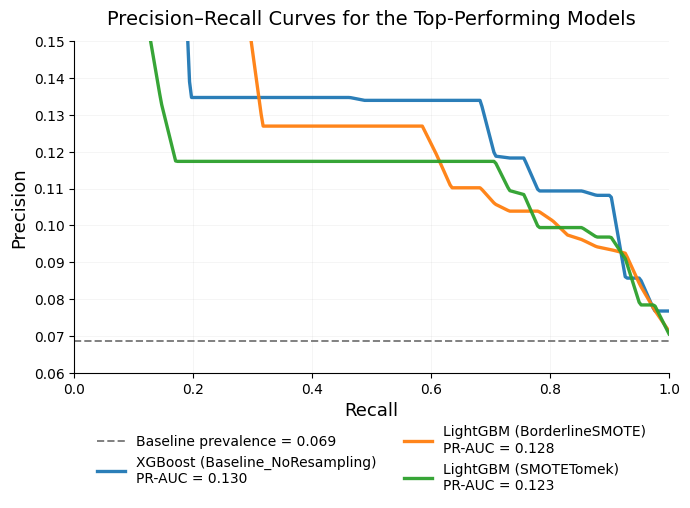

In [40]:
# ==========================================
# Precision–Recall Curves for Top-Performing Models
# Paper-ready version (Test2 - LightGBM + wider param grid)
# ==========================================

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import os

top_n = 3

top_models_df = imbalance_results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).head(top_n)

os.makedirs("reports_test2/figures/pr_curves", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")
ax.set_facecolor("white")

baseline_prevalence = y_test.mean()

ax.axhline(
    baseline_prevalence,
    linestyle="--",
    color="gray",
    linewidth=1.4,
    label=f"Baseline prevalence = {baseline_prevalence:.3f}"
)

recall_grid = np.linspace(0, 1, 300)

for _, row in top_models_df.iterrows():

    model_name  = row["Model"]
    method_name = row["Imbalance_Method"]
    pr_auc      = row["PR-AUC"]

    model_key = f"{model_name}__{method_name}"
    y_prob    = imbalance_models[model_key]["probs"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    order     = np.argsort(recall)
    recall    = recall[order]
    precision = precision[order]

    uniq_recall    = np.unique(recall)
    uniq_precision = np.array([
        precision[recall == r].max() for r in uniq_recall
    ])

    precision_env    = np.maximum.accumulate(uniq_precision[::-1])[::-1]
    precision_smooth = np.interp(recall_grid, uniq_recall, precision_env)

    label = f"{model_name} ({method_name})\nPR-AUC = {pr_auc:.3f}"

    ax.plot(
        recall_grid,
        precision_smooth,
        linewidth=2.4,
        alpha=0.95,
        label=label
    )

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision–Recall Curves for the Top-Performing Models", fontsize=14, pad=12)

ax.set_xlim(0, 1)
ax.set_ylim(0.06, 0.15)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.15, linewidth=0.6)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 0.97])

plt.savefig(
    "reports_test2/figures/pr_curves/top_models_pr_curve_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### 4. Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด

In [41]:
# ==========================================
# Feature Budget Optimization (XGBoost + Baseline)
# Test2 - LightGBM + wider param grid
# ==========================================

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.base import clone
import numpy as np
import pandas as pd

# ดึง final model
final_model_key = "XGBoost__Baseline_NoResampling"
xgb_model = imbalance_models[final_model_key]["model"]

import xgboost as xgb

booster = xgb_model.named_steps["model"] if hasattr(xgb_model, "named_steps") else xgb_model

feat_importance = pd.Series(
    booster.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 features by importance:")
print(feat_importance.head(20))

# -----------------------------
# Feature budget loop
# -----------------------------
group_cv_budget = GroupKFold(n_splits=3)
budget_results  = []

for k in range(1, len(feat_importance) + 1):

    top_k_features = feat_importance.index[:k].tolist()
    X_train_k      = X_train[top_k_features]
    model_k        = clone(booster)

    scores = cross_val_score(
        model_k,
        X_train_k,
        y_train,
        groups=groups_train,
        cv=group_cv_budget,
        scoring="average_precision",
        n_jobs=-1
    )

    budget_results.append({
        "Num_Features": k,
        "PR-AUC":       scores.mean(),
        "PR-AUC_std":   scores.std()
    })

    if k % 10 == 0 or k == 1:
        print(f"  k={k:3d}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

budget_df_xgb = pd.DataFrame(budget_results)

# -----------------------------
# หา optimal k
# -----------------------------
max_score_xgb = budget_df_xgb["PR-AUC"].max()
max_idx       = budget_df_xgb["PR-AUC"].idxmax()
se_at_max     = budget_df_xgb.loc[max_idx, "PR-AUC_std"] / np.sqrt(3)
threshold_1se = max_score_xgb - se_at_max

optimal_k_xgb = budget_df_xgb.loc[
    budget_df_xgb["PR-AUC"] >= threshold_1se,
    "Num_Features"
].min()

print(f"\nMax PR-AUC: {max_score_xgb:.4f} at k={budget_df_xgb.loc[max_idx, 'Num_Features']}")
print(f"1-SE threshold: {threshold_1se:.4f}")
print(f"Optimal k (1-SE rule): {optimal_k_xgb}")

# -----------------------------
# Save budget table
# -----------------------------
os.makedirs("reports_test2/tables", exist_ok=True)
budget_df_xgb.to_excel(
    "reports_test2/tables/feature_budget_xgb.xlsx",
    index=False
)

print("\n✅ Feature budget optimization complete")
print(budget_df_xgb.head(10))

Top 20 features by importance:
Uterine_Factors                    0.072786
Total_Female_Pathology             0.044324
Ovulatory_Factors                  0.038748
Cycle_Day                          0.035701
Post_TPMSC                         0.032033
First_Count                        0.031462
Pre_Count                          0.030733
Gynecological_Surgical_History     0.028473
Post_Count                         0.027636
Delta_Motile                       0.027509
Age_Female                         0.026809
First_Progressive_Motile           0.025780
First_Volume                       0.024898
Menstrual_Interval_Days            0.023784
First_Motile                       0.023175
BMI_InfertilityType_Interaction    0.023122
First_TotalMotile                  0.022979
Menstrual_Duration_Days            0.022453
Delta_Progressive_Motile           0.022102
Ratio_TPMSC                        0.021760
dtype: float32
  k=  1: PR-AUC = 0.0786 ± 0.0053
  k= 10: PR-AUC = 0.1207 ± 0.0245
  k= 2

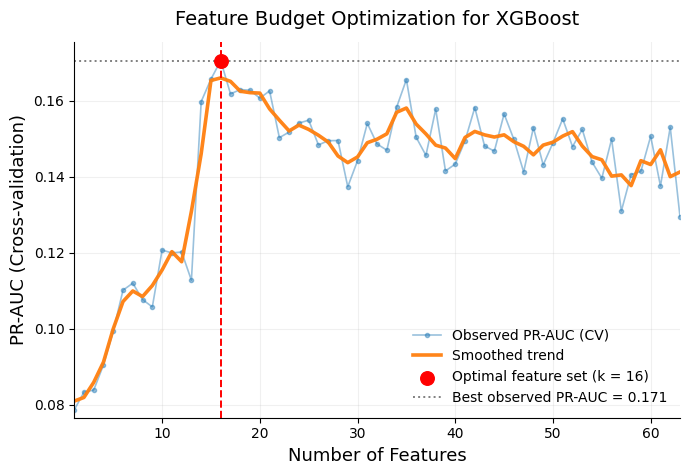

In [42]:
# ==========================================
# Feature Budget Optimization (XGBoost)
# Paper-ready figure (Test2 - LightGBM + wider param grid)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("reports_test2/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor("white")

x = budget_df_xgb["Num_Features"]
y = budget_df_xgb["PR-AUC"]

y_smooth = y.rolling(window=3, center=True, min_periods=1).mean()

ax.plot(
    x, y,
    marker="o",
    markersize=3,
    lw=1.2,
    alpha=0.45,
    label="Observed PR-AUC (CV)"
)

ax.plot(
    x, y_smooth,
    lw=2.6,
    alpha=0.95,
    label="Smoothed trend"
)

opt_y = budget_df_xgb.loc[
    budget_df_xgb["Num_Features"] == optimal_k_xgb,
    "PR-AUC"
].iloc[0]

ax.scatter(
    optimal_k_xgb, opt_y,
    s=95,
    color="red",
    zorder=6,
    label=f"Optimal feature set (k = {optimal_k_xgb})"
)

ax.axhline(
    y=max_score_xgb,
    linestyle=":",
    linewidth=1.4,
    color="gray",
    label=f"Best observed PR-AUC = {max_score_xgb:.3f}"
)

ax.axvline(
    x=optimal_k_xgb,
    linestyle="--",
    linewidth=1.4,
    color="red"
)

ax.set_xlabel("Number of Features", fontsize=13)
ax.set_ylabel("PR-AUC (Cross-validation)", fontsize=13)
ax.set_title("Feature Budget Optimization for XGBoost", fontsize=14, pad=12)

ax.set_xlim(1, x.max())
ax.set_ylim(y.min() - 0.002, y.max() + 0.005)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)

ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "reports_test2/figures/feature_budget_xgb_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [43]:
# ==========================================
# Block 6B: Retrain XGBoost with optimal k features
# Final model: XGBoost + Baseline_NoResampling
# Test2 - LightGBM + wider param grid
# ==========================================

from xgboost import XGBClassifier
import joblib
import os

# -----------------------------
# เลือก top k features จาก budget optimization
# -----------------------------
selected_features_xgb = feat_importance.index[:optimal_k_xgb].tolist()

print(f"Selected {optimal_k_xgb} features:")
for i, f in enumerate(selected_features_xgb, start=1):
    print(f"  {i}. {f}")

X_train_final = X_train[selected_features_xgb].copy()
X_test_final  = X_test[selected_features_xgb].copy()

# -----------------------------
# Retrain XGBoost ด้วย best params จาก imbalance block
# -----------------------------
best_params = imbalance_models["XGBoost__Baseline_NoResampling"]["best_params"]

clean_params = {
    k.replace("model__", ""): v
    for k, v in best_params.items()
}

final_xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    **clean_params
)

final_xgb_model.fit(X_train_final, y_train)

print(f"\n✅ Retrained XGBoost with {optimal_k_xgb} features")
print(f"Best params used: {clean_params}")

# save
os.makedirs("models_test2/final_model", exist_ok=True)
joblib.dump(
    final_xgb_model,
    "models_test2/final_model/XGBoost_Baseline_final_feature_budget_model.joblib"
)

Selected 16 features:
  1. Uterine_Factors
  2. Total_Female_Pathology
  3. Ovulatory_Factors
  4. Cycle_Day
  5. Post_TPMSC
  6. First_Count
  7. Pre_Count
  8. Gynecological_Surgical_History
  9. Post_Count
  10. Delta_Motile
  11. Age_Female
  12. First_Progressive_Motile
  13. First_Volume
  14. Menstrual_Interval_Days
  15. First_Motile
  16. BMI_InfertilityType_Interaction

✅ Retrained XGBoost with 16 features
Best params used: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.005, 'colsample_bytree': 0.8}


['models_test2/final_model/XGBoost_Baseline_final_feature_budget_model.joblib']

Final features used:
  1. Uterine_Factors
  2. Total_Female_Pathology
  3. Ovulatory_Factors
  4. Cycle_Day
  5. Post_TPMSC
  6. First_Count
  7. Pre_Count
  8. Gynecological_Surgical_History
  9. Post_Count
  10. Delta_Motile
  11. Age_Female
  12. First_Progressive_Motile
  13. First_Volume
  14. Menstrual_Interval_Days
  15. First_Motile
  16. BMI_InfertilityType_Interaction

Final model performance on test set:
PR-AUC:  0.1409
ROC-AUC: 0.6885
Brier:   0.2201

Top SHAP features:
                            Feature               Feature_Display  Importance
0                   Uterine_Factors                Uterine Factor    0.251988
1            Total_Female_Pathology        Total Female Pathology    0.081744
2                        Post_TPMSC                Postwash TPMSC    0.052324
3           Menstrual_Interval_Days         Cycle Interval (days)    0.050909
4                         Pre_Count           Prewash Sperm Count    0.038010
5                      Delta_Motile          

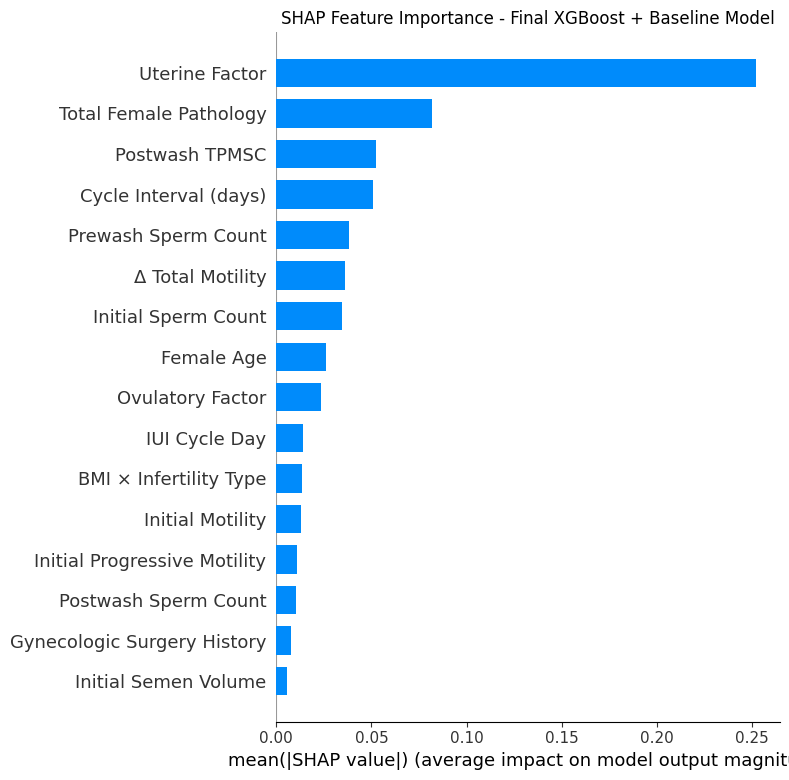

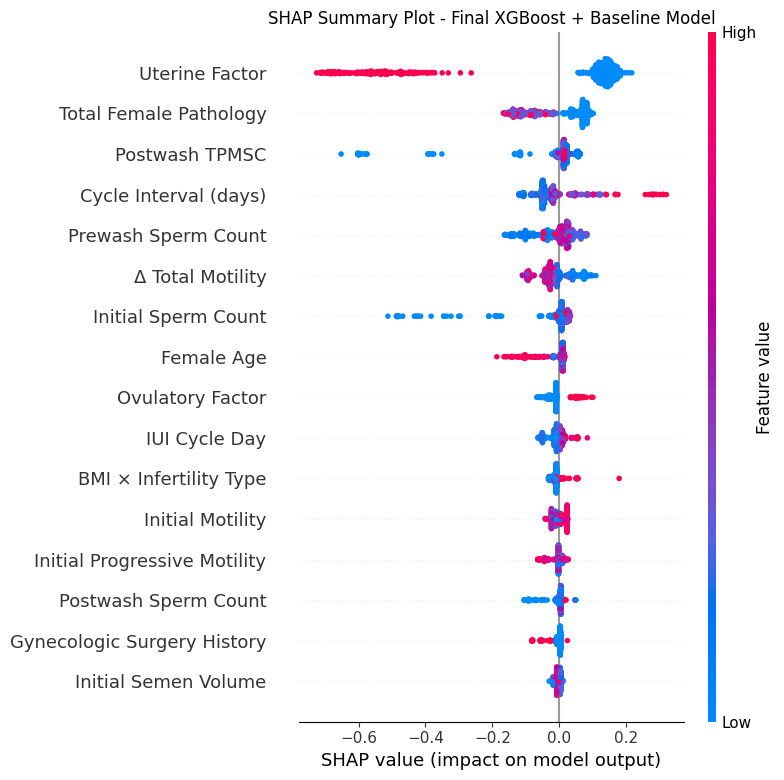


✅ Block 7 complete
Saved files:
- models_test2/final_model/XGBoost_Baseline_final_feature_budget_model.joblib
- reports_test2/tables/Final_Model_Performance_XGBoost_Baseline.xlsx
- reports_test2/tables/Final_Selected_Features_XGBoost_Baseline.xlsx
- reports_test2/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx
- reports_test2/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx
- reports_test2/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png
- reports_test2/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png


In [44]:
# ==========================================
# Block 7: Final Model Evaluation + SHAP Analysis
# Final model = XGBoost + Baseline after feature budget
# Test2 - LightGBM + wider param grid
# ==========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)

os.makedirs("reports_test2/figures/shap_final_xgb", exist_ok=True)
os.makedirs("reports_test2/tables", exist_ok=True)
os.makedirs("models_test2/final_model", exist_ok=True)

required_objects = [
    "selected_features_xgb",
    "final_xgb_model",
    "X_test",
    "y_test",
    "test_info"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

final_features = selected_features_xgb.copy()

missing_features = [f for f in final_features if f not in X_test.columns]
if missing_features:
    raise ValueError(f"These final features are missing from X_test: {missing_features}")

X_test_final = X_test[final_features].copy()

print("Final features used:")
for i, f in enumerate(final_features, start=1):
    print(f"  {i}. {f}")

final_probs   = final_xgb_model.predict_proba(X_test_final)[:, 1]
final_pr_auc  = average_precision_score(y_test, final_probs)
final_roc_auc = roc_auc_score(y_test, final_probs)
final_brier   = brier_score_loss(y_test, final_probs)

print("\nFinal model performance on test set:")
print(f"PR-AUC:  {final_pr_auc:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Brier:   {final_brier:.4f}")

final_model_summary = pd.DataFrame([{
    "Model": "XGBoost + Baseline (Final Feature-Budget Model)",
    "Num_Features": len(final_features),
    "PR-AUC":  final_pr_auc,
    "ROC-AUC": final_roc_auc,
    "Brier":   final_brier
}])

final_model_summary.to_excel(
    "reports_test2/tables/Final_Model_Performance_XGBoost_Baseline.xlsx",
    index=False
)

final_features_df = pd.DataFrame({
    "Rank":    range(1, len(final_features) + 1),
    "Feature": final_features
})

final_features_df.to_excel(
    "reports_test2/tables/Final_Selected_Features_XGBoost_Baseline.xlsx",
    index=False
)

final_test_pred_df = test_info.copy()
final_test_pred_df["y_true"] = y_test.values
final_test_pred_df["y_prob"] = final_probs

final_test_pred_df.to_excel(
    "reports_test2/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx",
    index=False
)

feature_name_map = {
    'Age_Female': 'Female Age',
    'Body_Mass_Index': 'BMI',
    'Total_infertile_duration': 'Infertility Duration',
    'Infertility_Type': 'Primary Infertility',
    'Pregnancy_History': 'Previous Pregnancy',
    'Number_Of_Alive_Children': 'Number of Children',
    'Number_Of_Miscarriages': 'Number of Miscarriages',
    'Menstrual': 'Regular Menstrual Cycle',
    'Menstrual_Interval_Days': 'Cycle Interval (days)',
    'Menstrual_Duration_Days': 'Menstrual Duration (days)',
    'Dysmenorrhea': 'Dysmenorrhea',
    'FSH_Baseline': 'Baseline FSH',
    'LH_Baseline': 'Baseline LH',
    'E2_Baseline': 'Baseline Estradiol',
    'PRL_Baseline': 'Baseline Prolactin',
    'Uterine_Factors': 'Uterine Factor',
    'Tubal_Factors': 'Tubal Factor',
    'Ovarian_Factors': 'Ovarian Factor',
    'Ovulatory_Factors': 'Ovulatory Factor',
    'Cervical_Factors': 'Cervical Factor',
    'Endometriosis_Factors': 'Endometriosis',
    'Multisystem_Factors': 'Multiple Infertility Factors',
    'Gynecological_Surgical_History': 'Gynecologic Surgery History',
    'Alcohol': 'Male Alcohol Consumption',
    'Smoke': 'Male Smoking',
    'First_Volume': 'Initial Semen Volume',
    'First_Count': 'Initial Sperm Count',
    'First_Motile': 'Initial Motility',
    'First_Progressive_Motile': 'Initial Progressive Motility',
    'First_Normal_Morpho': 'Initial Normal Morphology',
    'Pre_Volume': 'Prewash Volume',
    'Pre_Count': 'Prewash Sperm Count',
    'Pre_Motile': 'Prewash Motility',
    'Pre_Progressive_Motile': 'Prewash Progressive Motility',
    'Pre_TPMSC': 'Prewash TPMSC',
    'Post_Count': 'Postwash Sperm Count',
    'Post_Motile': 'Postwash Motility',
    'Post_Progressive_Motile': 'Postwash Progressive Motility',
    'Post_TPMSC': 'Postwash TPMSC',
    'Cycle_Type': 'Cycle Type',
    'Cycle_Day': 'IUI Cycle Day',
    'Cycle_Number': 'IUI Cycle Number',
    'Ovary_Stimulation_Round': 'Stimulation Round',
    'OI_Clomiphene': 'Clomiphene',
    'OI_Letrozole': 'Letrozole',
    'OI_Gonadotropins': 'Gonadotropins',
    'hCG_Used': 'hCG Trigger Used',
    'hCG_Type': 'hCG Type',
    'Mature_Follicle_Count': 'Mature Follicle Count',
    'Endometrium_Thickness': 'Endometrial Thickness',
    'Endo_Type_Triple': 'Triple Line Endometrium',
    'Endo_Type_Intermediate': 'Intermediate Endometrium',
    'Endo_Type_Mixed': 'Mixed Endometrium',
    'Ratio_TPMSC': 'TPMSC Wash Ratio',
    'Delta_Progressive_Motile': 'Δ Progressive Motility',
    'Delta_Motile': 'Δ Total Motility',
    'Follicle_Endo_Product': 'Follicle × Endometrium',
    'Cumulative_Treatment': 'Cumulative Treatment',
    'Age_FSH_Interaction': 'Age × FSH',
    'BMI_InfertilityType_Interaction': 'BMI × Infertility Type',
    'Total_Female_Pathology': 'Total Female Pathology',
    'First_TotalMotile': 'Initial Total Motile Sperm'
}

display_names              = [feature_name_map.get(f, f) for f in final_features]
X_test_final_named         = X_test_final.copy()
X_test_final_named.columns = display_names

explainer   = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_test_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

if not isinstance(shap_values, np.ndarray):
    raise ValueError("Unexpected SHAP output format.")

if shap_values.shape[1] != X_test_final.shape[1]:
    raise ValueError(
        f"SHAP shape mismatch: shap_values has {shap_values.shape[1]} features, "
        f"but X_test_final has {X_test_final.shape[1]} features."
    )

feat_imp_final_xgb = pd.DataFrame({
    "Feature":         final_features,
    "Feature_Display": display_names,
    "Importance":      np.abs(shap_values).mean(axis=0)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_imp_final_xgb.to_excel(
    "reports_test2/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx",
    index=False
)

print("\nTop SHAP features:")
print(feat_imp_final_xgb.to_string())

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    plot_type="bar",
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Feature Importance - Final XGBoost + Baseline Model")
plt.tight_layout()
plt.savefig(
    "reports_test2/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Summary Plot - Final XGBoost + Baseline Model")
plt.tight_layout()
plt.savefig(
    "reports_test2/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("\n✅ Block 7 complete")
print("Saved files:")
print("- models_test2/final_model/XGBoost_Baseline_final_feature_budget_model.joblib")
print("- reports_test2/tables/Final_Model_Performance_XGBoost_Baseline.xlsx")
print("- reports_test2/tables/Final_Selected_Features_XGBoost_Baseline.xlsx")
print("- reports_test2/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx")
print("- reports_test2/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx")
print("- reports_test2/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png")
print("- reports_test2/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png")

HN overlap between subtrain and calibration set: 0
Subtrain size: 1867
Calibration size: 481
Subtrain positives: 112 / 1867
Calibration positives: 30 / 481

Brier before calibration: 0.2172
Brier after calibration:  0.0644
Improvement:              0.1528

Raw probability summary:
count    597.000000
mean       0.453074
std        0.116707
min        0.179240
25%        0.360830
50%        0.492012
75%        0.554180
max        0.633507
dtype: float64

Calibrated probability summary:
count    597.000000
mean       0.065414
std        0.054308
min        0.000000
25%        0.023256
50%        0.055556
75%        0.106383
max        0.664468
dtype: float64


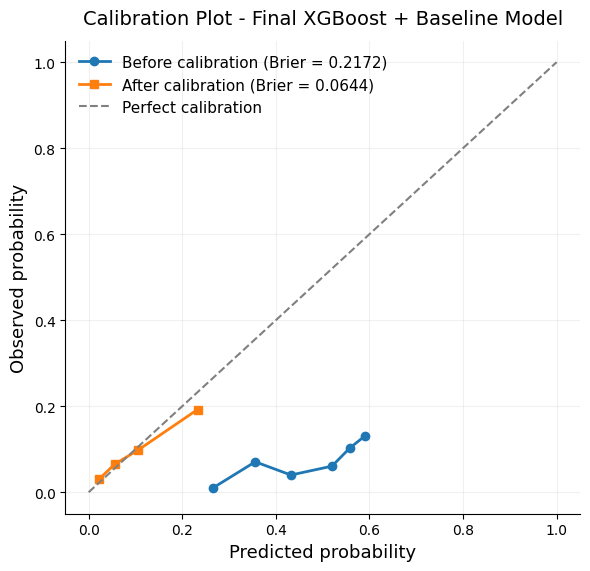


✅ Group-aware calibration complete
Saved files:
- reports_test2/tables/Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx
- reports_test2/figures/Calibration_Plot_Final_XGBoost_Baseline.png
- models_test2/final_model/XGBoost_Baseline_calibration_base_model.joblib
- models_test2/final_model/isotonic_calibrator_final_xgb.joblib


In [66]:
# ==========================================
# Calibration Plot - Final XGBoost + Baseline Model
# Before and After Calibration (GROUP-AWARE proper calibration split)
# Test2 - LightGBM + wider param grid
# ==========================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GroupShuffleSplit
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import joblib

os.makedirs("reports_test2/figures", exist_ok=True)
os.makedirs("reports_test2/tables", exist_ok=True)
os.makedirs("models_test2/final_model", exist_ok=True)

# -----------------------------
# Required objects check
# -----------------------------
required_objects = [
    "X_train_final",
    "X_test_final",
    "y_train",
    "y_test",
    "groups_train",
    "clean_params"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

# -----------------------------
# Align groups_train to X_train_final index
# -----------------------------
if isinstance(groups_train, pd.Series):
    groups_train_aligned = groups_train.loc[X_train_final.index].copy()
else:
    groups_train_aligned = pd.Series(groups_train, index=X_train_final.index, name="HN")

if len(groups_train_aligned) != len(X_train_final):
    raise ValueError("groups_train length does not match X_train_final length.")

# -----------------------------
# Group-aware split:
# subtrain for model fitting
# calibration set for isotonic regression
# -----------------------------
gss_cal = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
subtrain_idx, cal_idx = next(
    gss_cal.split(X_train_final, y_train, groups=groups_train_aligned)
)

X_subtrain = X_train_final.iloc[subtrain_idx].copy()
y_subtrain = y_train.iloc[subtrain_idx].copy()

X_cal = X_train_final.iloc[cal_idx].copy()
y_cal = y_train.iloc[cal_idx].copy()

groups_subtrain = groups_train_aligned.iloc[subtrain_idx].copy()
groups_cal = groups_train_aligned.iloc[cal_idx].copy()

# -----------------------------
# Sanity check: no patient overlap
# -----------------------------
overlap = set(groups_subtrain).intersection(set(groups_cal))
print(f"HN overlap between subtrain and calibration set: {len(overlap)}")
assert len(overlap) == 0, "Patient leakage detected between subtrain and calibration set."

print(f"Subtrain size: {len(X_subtrain)}")
print(f"Calibration size: {len(X_cal)}")
print(f"Subtrain positives: {int(y_subtrain.sum())} / {len(y_subtrain)}")
print(f"Calibration positives: {int(y_cal.sum())} / {len(y_cal)}")

# -----------------------------
# Recompute pos_weight on subtrain only
# -----------------------------
pos_weight_subtrain = float(
    (len(y_subtrain) - y_subtrain.sum()) / max(y_subtrain.sum(), 1)
)

# -----------------------------
# Fit base XGBoost on subtrain
# -----------------------------
xgb_for_cal = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight_subtrain,
    **clean_params
)

xgb_for_cal.fit(X_subtrain, y_subtrain)

# -----------------------------
# Fit isotonic calibrator on calibration set
# -----------------------------
cal_probs_raw = xgb_for_cal.predict_proba(X_cal)[:, 1]

iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(cal_probs_raw, y_cal)

# -----------------------------
# Predict on TEST set
# -----------------------------
test_probs_raw = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = iso_reg.predict(test_probs_raw)
test_probs_calibrated = np.clip(test_probs_calibrated, 0, 1)

# -----------------------------
# Metrics
# -----------------------------
brier_before = brier_score_loss(y_test, test_probs_raw)
brier_after  = brier_score_loss(y_test, test_probs_calibrated)

print(f"\nBrier before calibration: {brier_before:.4f}")
print(f"Brier after calibration:  {brier_after:.4f}")
print(f"Improvement:              {brier_before - brier_after:.4f}")

print("\nRaw probability summary:")
print(pd.Series(test_probs_raw).describe())

print("\nCalibrated probability summary:")
print(pd.Series(test_probs_calibrated).describe())

# -----------------------------
# Save probability table
# -----------------------------
calibration_pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "prob_raw": test_probs_raw,
    "prob_calibrated": test_probs_calibrated
})

calibration_pred_df.to_excel(
    "reports_test2/tables/Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Save model objects for deployment
# IMPORTANT: these two must be used together
# -----------------------------
joblib.dump(
    xgb_for_cal,
    "models_test2/final_model/XGBoost_Baseline_calibration_base_model.joblib"
)

joblib.dump(
    iso_reg,
    "models_test2/final_model/isotonic_calibrator_final_xgb.joblib"
)

# -----------------------------
# Calibration curves
# -----------------------------
prob_true_before, prob_pred_before = calibration_curve(
    y_test,
    test_probs_raw,
    n_bins=6,
    strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test,
    test_probs_calibrated,
    n_bins=6,
    strategy="quantile"
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    linewidth=2,
    label=f"Before calibration (Brier = {brier_before:.4f})"
)

ax.plot(
    prob_pred_after,
    prob_true_after,
    marker="s",
    linewidth=2,
    label=f"After calibration (Brier = {brier_after:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration"
)

ax.set_xlabel("Predicted probability", fontsize=13)
ax.set_ylabel("Observed probability", fontsize=13)
ax.set_title("Calibration Plot - Final XGBoost + Baseline Model", fontsize=14, pad=12)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "reports_test2/figures/Calibration_Plot_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

print("\n✅ Group-aware calibration complete")
print("Saved files:")
print("- reports_test2/tables/Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx")
print("- reports_test2/figures/Calibration_Plot_Final_XGBoost_Baseline.png")
print("- models_test2/final_model/XGBoost_Baseline_calibration_base_model.joblib")
print("- models_test2/final_model/isotonic_calibrator_final_xgb.joblib")

Dependence features to plot: ['Uterine_Factors', 'Total_Female_Pathology', 'Menstrual_Interval_Days', 'Post_TPMSC', 'Pre_Count', 'First_Count', 'Delta_Motile', 'Age_Female', 'Ovulatory_Factors']


<Figure size 800x600 with 0 Axes>

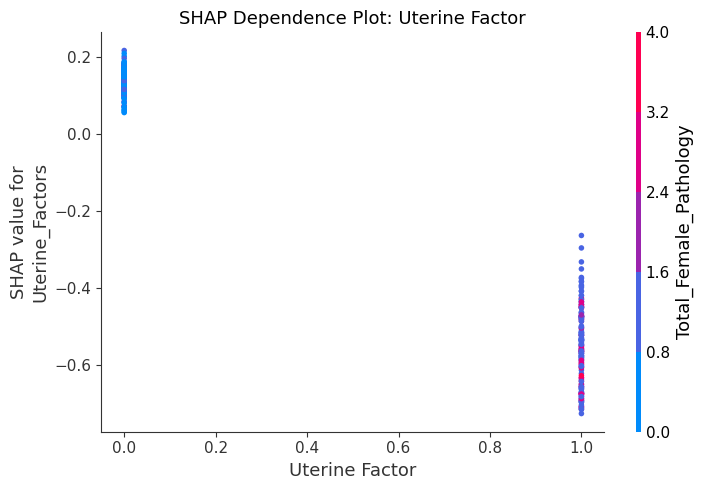

<Figure size 800x600 with 0 Axes>

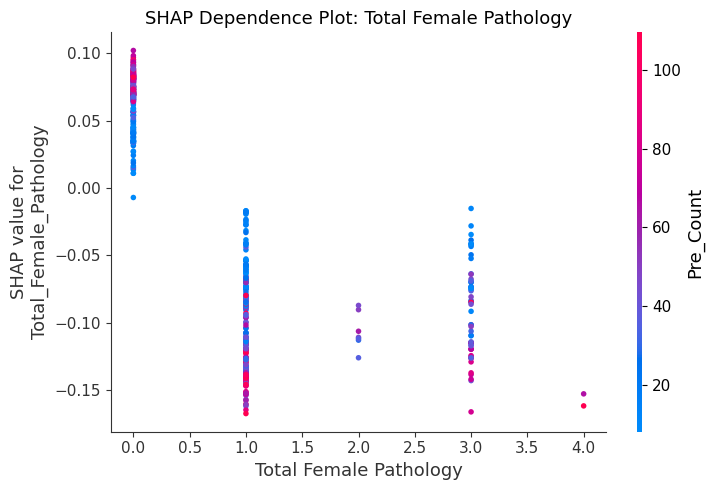

<Figure size 800x600 with 0 Axes>

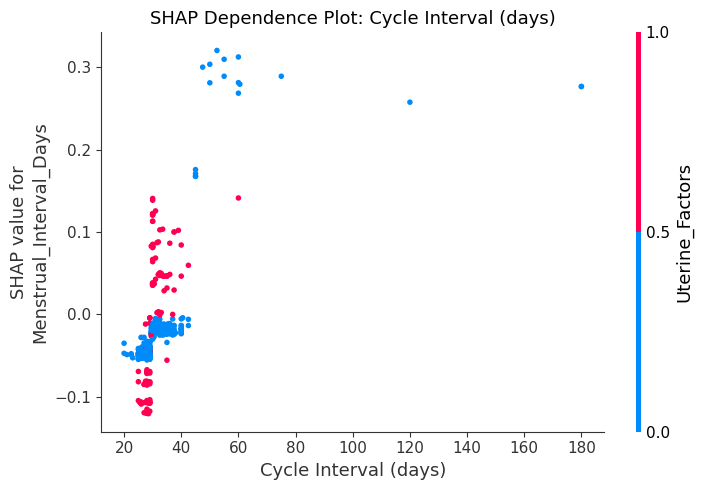

<Figure size 800x600 with 0 Axes>

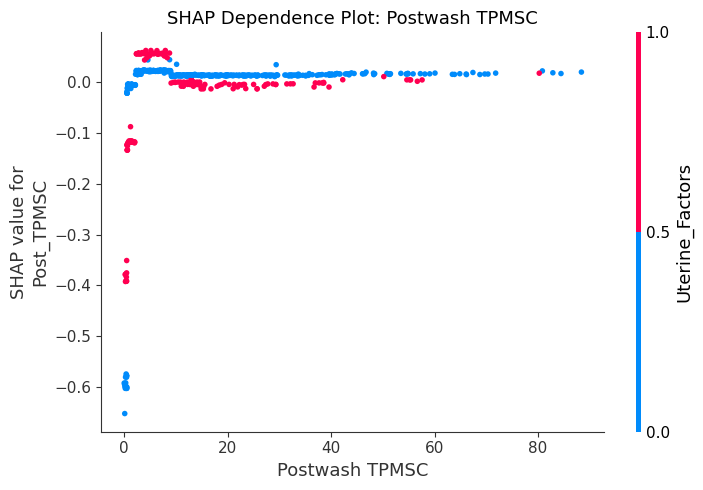

<Figure size 800x600 with 0 Axes>

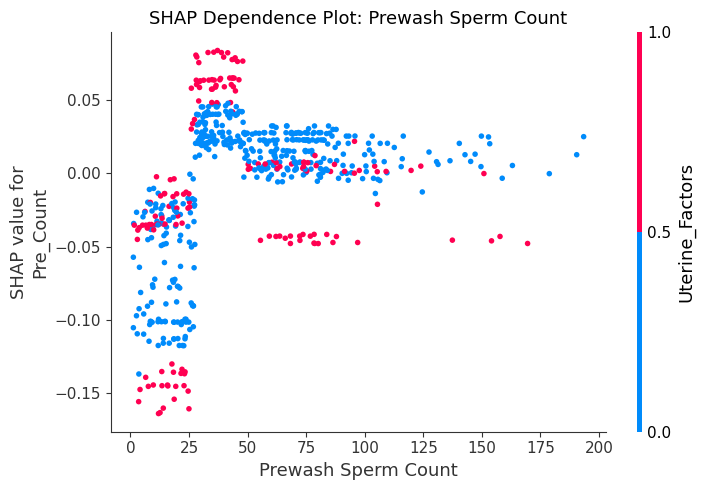

<Figure size 800x600 with 0 Axes>

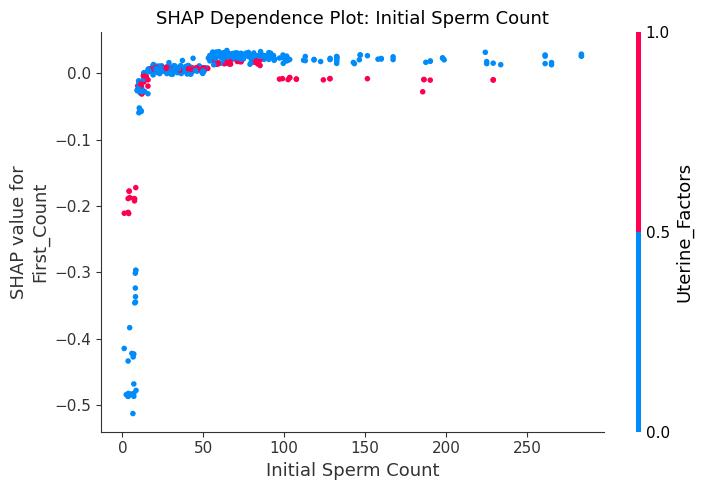

<Figure size 800x600 with 0 Axes>

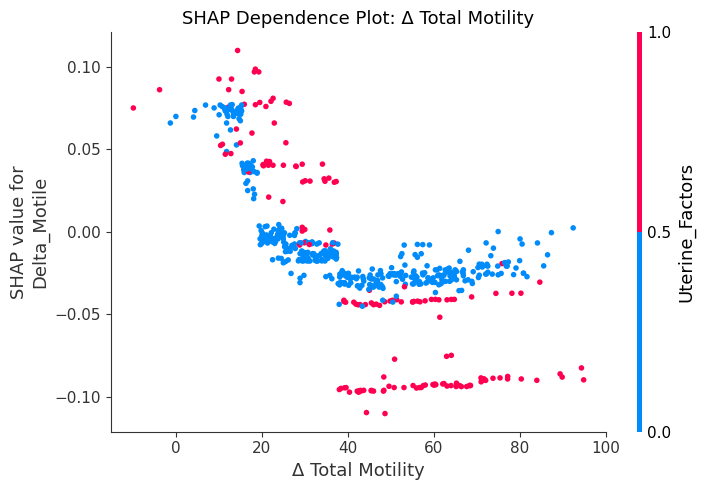

<Figure size 800x600 with 0 Axes>

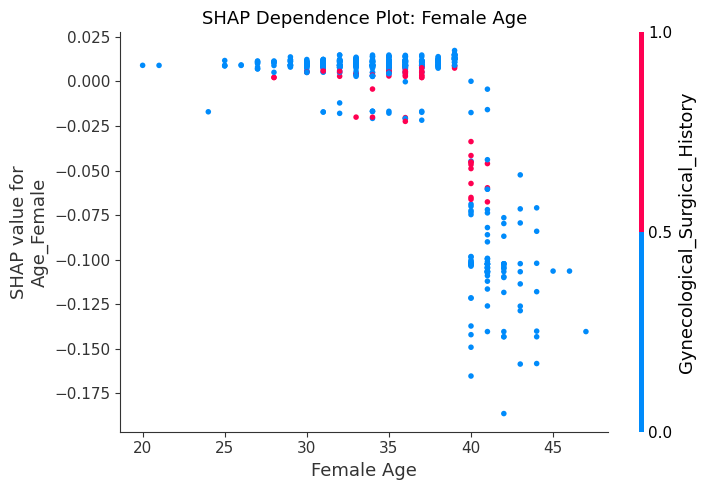

<Figure size 800x600 with 0 Axes>

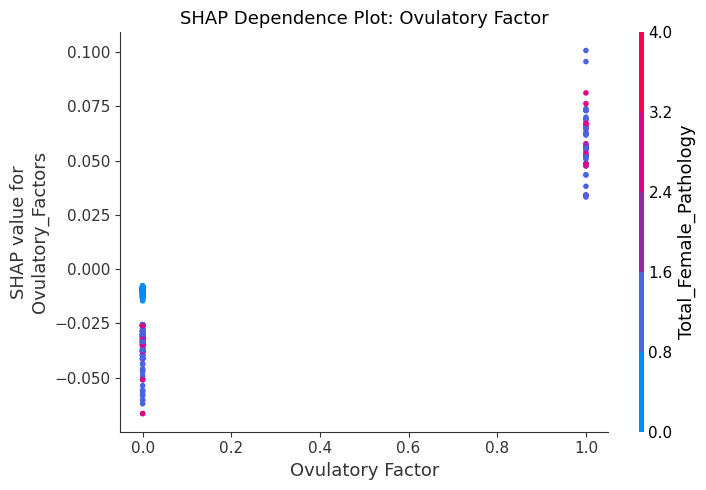

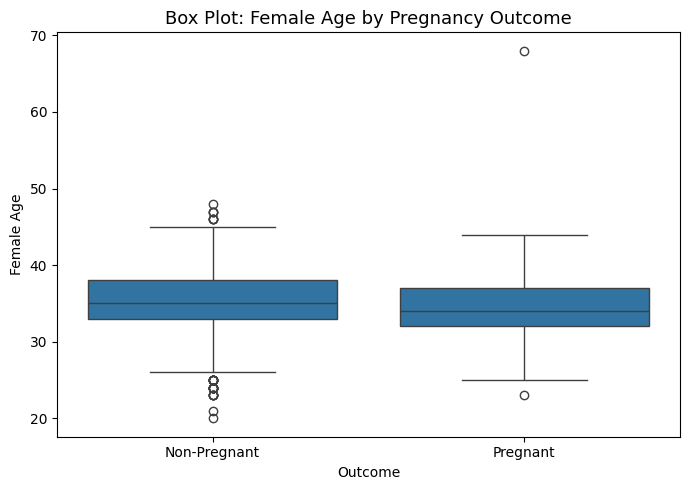

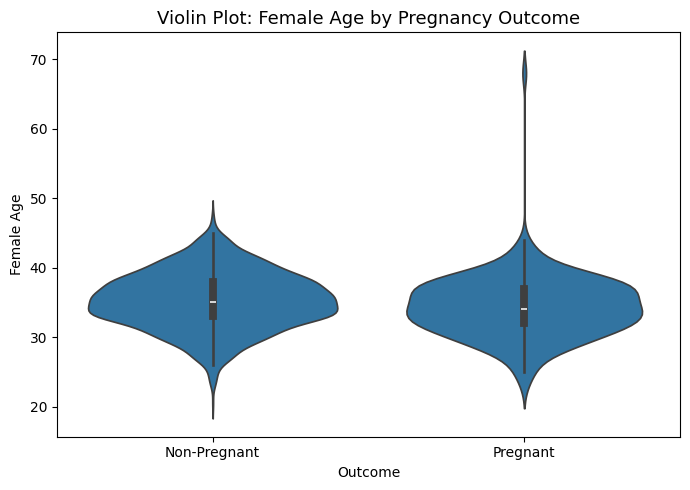

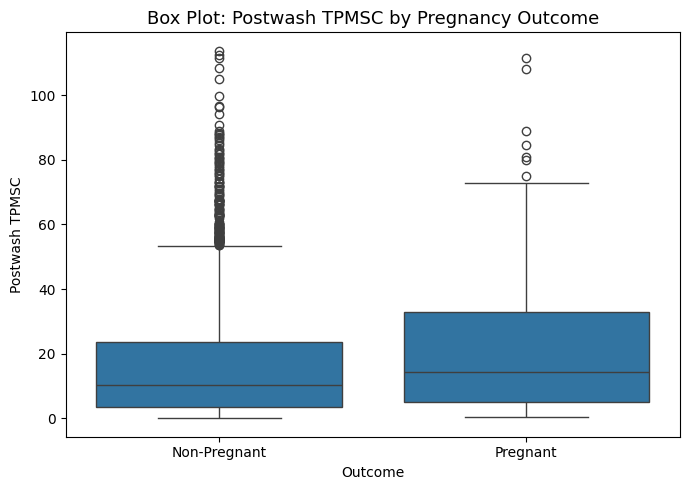

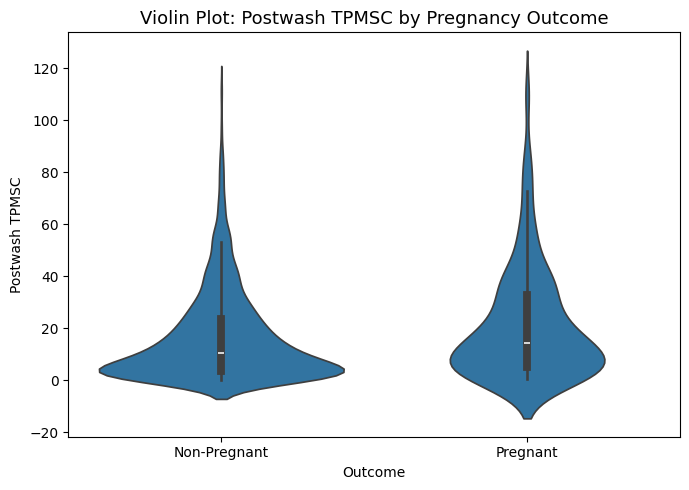

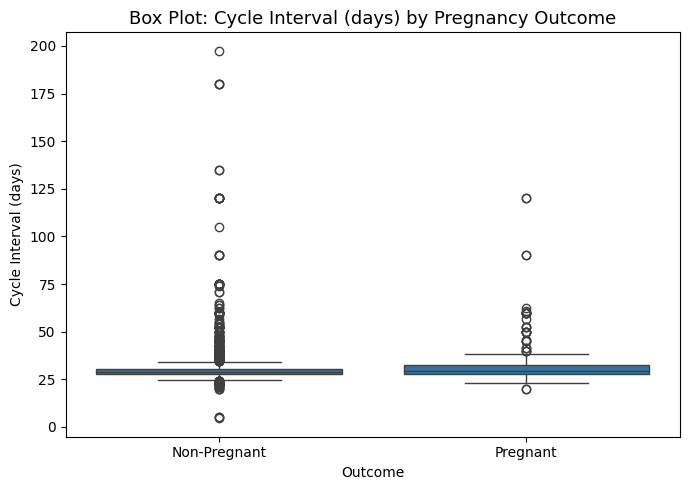

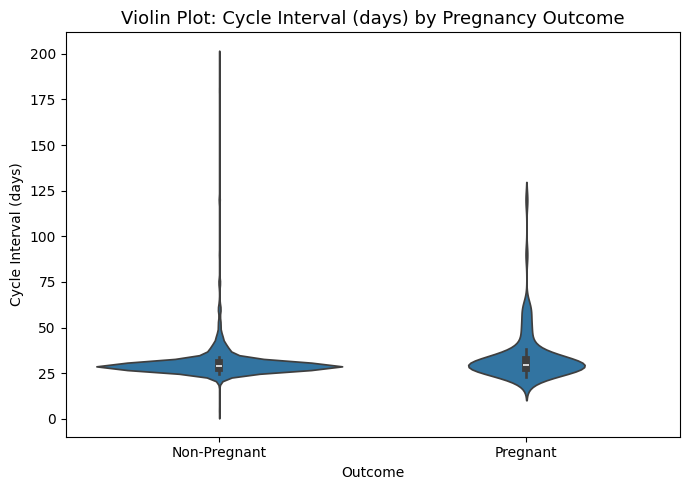

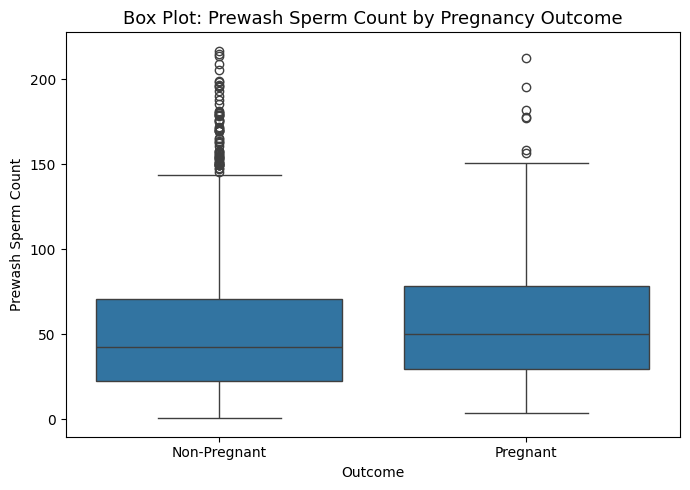

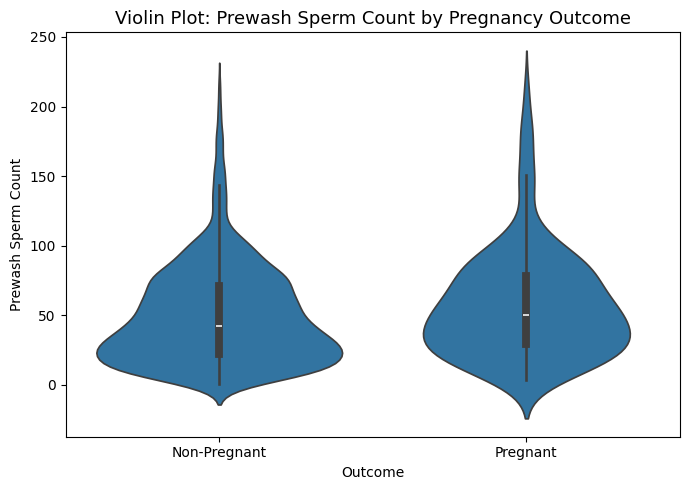

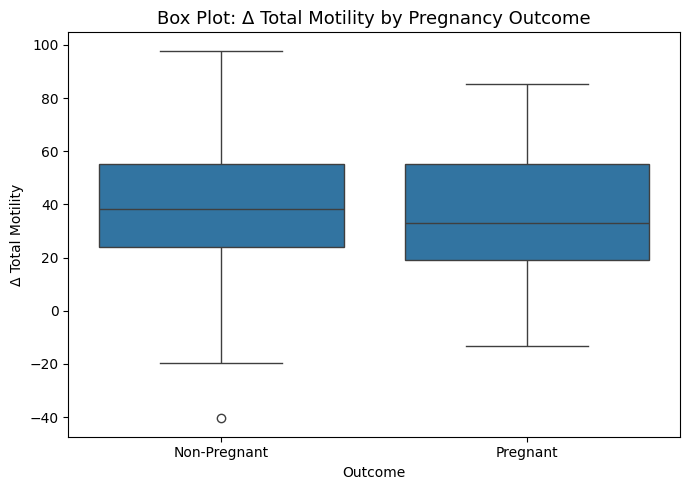

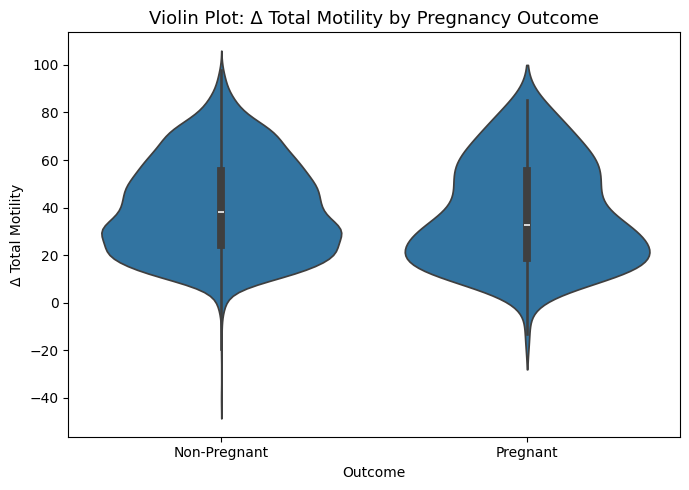

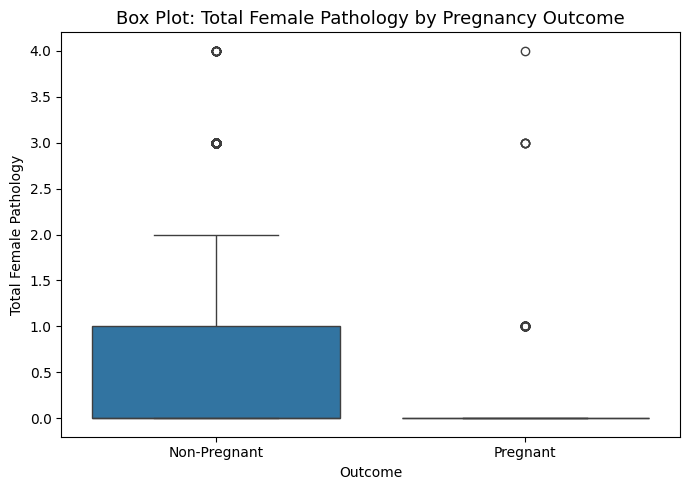

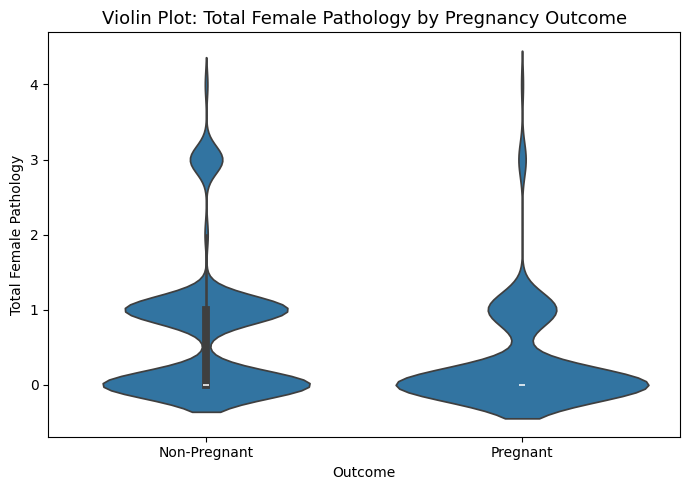

<Figure size 800x600 with 0 Axes>

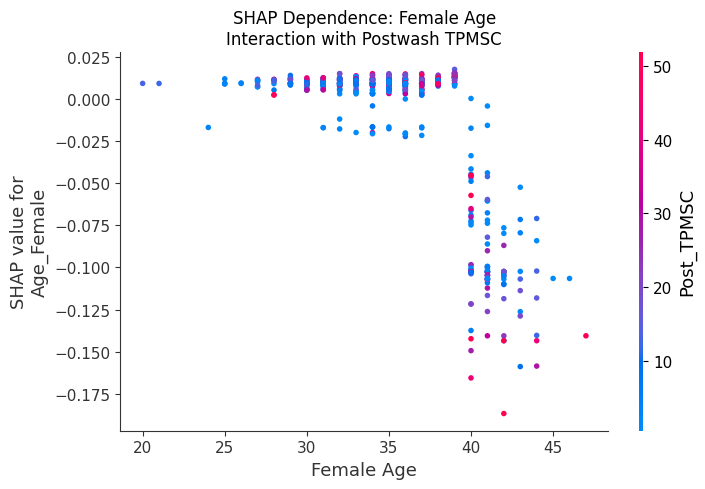


✅ SHAP Dependence + Clinical Plots complete


In [56]:
# =========================
# 4.3 SHAP Dependence Plots
# =========================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

os.makedirs('reports_test2/figures/shap_dependence', exist_ok=True)
os.makedirs('reports_test2/figures/clinical_plots', exist_ok=True)

# ใช้ object จาก final model block
for obj_name in ['feat_imp_final_xgb', 'shap_values', 'X_test_final', 'final_features']:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run final SHAP block first.")

# เลือก dependence features จาก 16 final features ที่มี SHAP importance สูง
candidate_dependence_features = [
    'Uterine_Factors',
    'Total_Female_Pathology',
    'Menstrual_Interval_Days',
    'Post_TPMSC',
    'Pre_Count',
    'First_Count',
    'Delta_Motile',
    'Age_Female',
    'Ovulatory_Factors',
]

top_feature_set = set(feat_imp_final_xgb['Feature'].head(15).tolist())
dependence_features = [
    f for f in candidate_dependence_features
    if f in X_test_final.columns and f in top_feature_set
]

print("Dependence features to plot:", dependence_features)

for feat in dependence_features:
    display_name = feature_name_map.get(feat, feat) if 'feature_name_map' in globals() else feat

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_final,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {display_name}', fontsize=13)
    plt.xlabel(display_name)
    plt.tight_layout()
    plt.savefig(
        f'reports_test2/figures/shap_dependence/SHAP_Dependence_{feat}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()


# ==========================================
# 4.4 Clinical Box / Violin Plots by Outcome
# ==========================================

# Descriptive plots on the full processed cohort for clinical visualization only
# (not a held-out test-set validation analysis)
plot_df = df.copy()
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]

plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df = plot_df.dropna(subset=['Result'])

plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

clinical_plot_features = [
    'Age_Female',
    'Post_TPMSC',
    'Menstrual_Interval_Days',
    'Pre_Count',
    'Delta_Motile',
    'Total_Female_Pathology',
]

for feat in clinical_plot_features:
    if feat in plot_df.columns:
        display_name = feature_name_map.get(feat, feat) if 'feature_name_map' in globals() else feat

        tmp = plot_df[['Pregnancy_Label', feat]].copy()
        tmp[feat] = pd.to_numeric(tmp[feat], errors='coerce')
        tmp = tmp.dropna(subset=[feat, 'Pregnancy_Label'])

        if tmp.empty:
            print(f"⚠️ ไม่มีข้อมูลใช้ plot สำหรับ {feat}")
            continue

        plt.figure(figsize=(7, 5))
        sns.boxplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat
        )
        plt.title(f'Box Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_test2/figures/clinical_plots/BoxPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
        plt.close()

        plt.figure(figsize=(7, 5))
        sns.violinplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat,
            inner='box'
        )
        plt.title(f'Violin Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_test2/figures/clinical_plots/ViolinPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
        plt.close()

    else:
        print(f"⚠️ ไม่พบคอลัมน์ {feat} ใน plot_df เลยข้ามไป")


# ==========================================
# 4.5 SHAP Interaction Plot
# Female Age × Post_TPMSC
# ==========================================

if {'Age_Female', 'Post_TPMSC'}.issubset(X_test_final.columns):
    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        'Age_Female',
        shap_values,
        X_test_final,
        interaction_index='Post_TPMSC',
        show=False
    )

    plt.title('SHAP Dependence: Female Age\nInteraction with Postwash TPMSC')
    plt.xlabel('Female Age')
    plt.tight_layout()

    plt.savefig(
        'reports_test2/figures/shap_dependence/SHAP_Dependence_FemaleAge_interaction_PostTPMSC.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

else:
    print("⚠️ ไม่พบ Age_Female หรือ Post_TPMSC ใน X_test_final")

print("\n✅ SHAP Dependence + Clinical Plots complete")

### 5. Clinical Analysis 1: Risk Stratification

Cutoff method: quantiles (0.25, 0.75)
Calibration-derived cutoffs: c1 = 0.023256, c2 = 0.055556


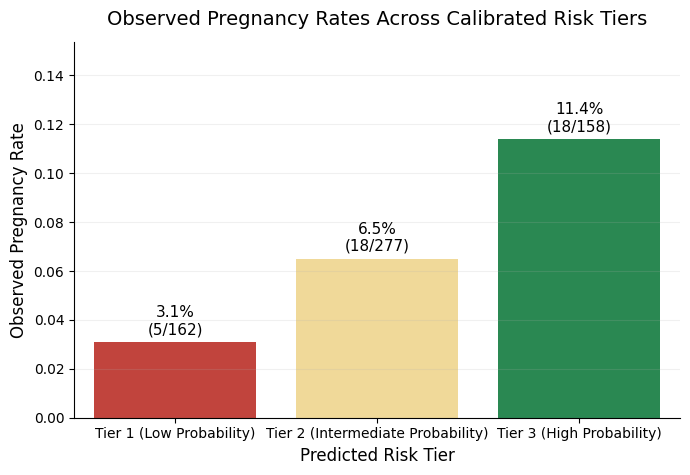


Calibration-set Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           135                   3   
1  Tier 2 (Intermediate Probability)           234                  13   
2          Tier 3 (High Probability)           112                  14   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.022222            0.000000            0.023256   
1            0.055556            0.055556            0.055556   
2            0.125000            0.106383            1.000000   

   Observed_Pregnancy_Rate  Predicted_minus_Observed      Dataset  
0                 0.022222              5.380975e-10  Calibration  
1                 0.055556              4.139211e-10  Calibration  
2                 0.125000              0.000000e+00  Calibration  

Test-set Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probabi

In [58]:
# =========================
# Block 8: Risk Tier Analysis (Robust clean version)
# Final calibrated model
# Cutoffs derived from calibration set, then applied to test set
# Handles tied calibrated probabilities safely
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_test2/tables', exist_ok=True)
os.makedirs('reports_test2/figures/clinical', exist_ok=True)

required_objects = [
    'X_cal',
    'y_cal',
    'xgb_for_cal',
    'iso_reg',
    'X_test_final',
    'y_test',
    'test_info'
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the group-aware calibration block first.")

# --------------------------------
# 1) Get calibrated probabilities
# --------------------------------
cal_probs_raw = xgb_for_cal.predict_proba(X_cal)[:, 1]
cal_probs_calibrated = np.clip(iso_reg.predict(cal_probs_raw), 0, 1)

test_probs_raw = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = np.clip(iso_reg.predict(test_probs_raw), 0, 1)

tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

# --------------------------------
# 2) Helper: robust cutoff selection
# --------------------------------
def get_robust_cutoffs(probs: np.ndarray):
    probs = np.asarray(probs, dtype=float)

    # Try tertiles first
    candidate_pairs = [
        (1/3, 2/3),
        (0.25, 0.75),
        (0.20, 0.80),
        (0.40, 0.70),
        (0.30, 0.70),
    ]

    for q1, q2 in candidate_pairs:
        c1 = float(np.quantile(probs, q1))
        c2 = float(np.quantile(probs, q2))
        if np.isfinite(c1) and np.isfinite(c2) and (c1 < c2):
            return c1, c2, f"quantiles ({q1:.2f}, {q2:.2f})"

    return None, None, "rank_fallback"

c1, c2, cutoff_method = get_robust_cutoffs(cal_probs_calibrated)

print("Cutoff method:", cutoff_method)
if c1 is not None and c2 is not None:
    print(f"Calibration-derived cutoffs: c1 = {c1:.6f}, c2 = {c2:.6f}")

# --------------------------------
# 3) Build calibration-set tiers
# --------------------------------
risk_cal_df = pd.DataFrame({
    'Predicted_Prob': cal_probs_calibrated,
    'Actual_Result': y_cal.values
})

if c1 is not None and c2 is not None:
    risk_cal_df['Risk_Tier'] = pd.cut(
        risk_cal_df['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_labels,
        include_lowest=True
    )
else:
    # Fallback for many ties: rank-based tiering on calibration set
    risk_cal_df = risk_cal_df.sort_values('Predicted_Prob', kind='mergesort').reset_index(drop=True)
    n = len(risk_cal_df)
    idx1 = int(np.floor(n / 3))
    idx2 = int(np.floor(2 * n / 3))

    risk_cal_df['Risk_Tier'] = tier_labels[0]
    risk_cal_df.loc[idx1:idx2-1, 'Risk_Tier'] = tier_labels[1]
    risk_cal_df.loc[idx2:, 'Risk_Tier'] = tier_labels[2]
    risk_cal_df['Risk_Tier'] = pd.Categorical(
        risk_cal_df['Risk_Tier'],
        categories=tier_labels,
        ordered=True
    )

# --------------------------------
# 4) Summarize calibration set
# --------------------------------
cal_tier_summary = (
    risk_cal_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

cal_tier_summary['Observed_Pregnancy_Rate'] = (
    cal_tier_summary['Actual_Pregnancies'] / cal_tier_summary['Total_Cycles']
)

cal_tier_summary['Predicted_minus_Observed'] = (
    cal_tier_summary['Avg_Predicted_Prob'] - cal_tier_summary['Observed_Pregnancy_Rate']
)

cal_tier_summary['Dataset'] = 'Calibration'

# --------------------------------
# 5) Apply same tier logic to TEST set
# --------------------------------
risk_df = test_info.copy()
risk_df['Predicted_Prob'] = test_probs_calibrated
risk_df['Actual_Result'] = y_test.values
risk_df = risk_df.dropna(subset=['Predicted_Prob', 'Actual_Result']).copy()

if c1 is not None and c2 is not None:
    risk_df['Risk_Tier'] = pd.cut(
        risk_df['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_labels,
        include_lowest=True
    )
else:
    # Apply rank-based tiering to test set using same 1/3 and 2/3 proportions
    risk_df = risk_df.sort_values('Predicted_Prob', kind='mergesort').reset_index(drop=True)
    n = len(risk_df)
    idx1 = int(np.floor(n / 3))
    idx2 = int(np.floor(2 * n / 3))

    risk_df['Risk_Tier'] = tier_labels[0]
    risk_df.loc[idx1:idx2-1, 'Risk_Tier'] = tier_labels[1]
    risk_df.loc[idx2:, 'Risk_Tier'] = tier_labels[2]
    risk_df['Risk_Tier'] = pd.Categorical(
        risk_df['Risk_Tier'],
        categories=tier_labels,
        ordered=True
    )

# --------------------------------
# 6) Summarize TEST set
# --------------------------------
tier_summary = (
    risk_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

if 'HN' in risk_df.columns:
    patient_counts = (
        risk_df
        .groupby('Risk_Tier', observed=False)['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )
    tier_summary = tier_summary.merge(patient_counts, on='Risk_Tier', how='left')

tier_summary['Observed_Pregnancy_Rate'] = (
    tier_summary['Actual_Pregnancies'] / tier_summary['Total_Cycles']
)

tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] - tier_summary['Observed_Pregnancy_Rate']
)

tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'],
    categories=tier_labels,
    ordered=True
)
tier_summary = tier_summary.sort_values('Risk_Tier').reset_index(drop=True)
tier_summary['Dataset'] = 'Test'

# --------------------------------
# 7) Save tables
# --------------------------------
cal_tier_summary.to_excel(
    'reports_test2/tables/Risk_Tier_Summary_CalibrationSet_Calibrated.xlsx',
    index=False
)

tier_summary.to_excel(
    'reports_test2/tables/Risk_Tier_Summary_FinalModel_Calibrated.xlsx',
    index=False
)

risk_df.to_excel(
    'reports_test2/tables/Risk_Tier_Assignments_TestSet_Calibrated.xlsx',
    index=False
)

# --------------------------------
# 8) Plot TEST set observed pregnancy rates
# --------------------------------
tier_colors = ['#d73027', '#fee08b', '#1a9850']

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

sns.barplot(
    x='Risk_Tier',
    y='Observed_Pregnancy_Rate',
    data=tier_summary,
    palette=tier_colors,
    ax=ax
)

ax.set_title(
    'Observed Pregnancy Rates Across Calibrated Risk Tiers',
    fontsize=14,
    pad=12
)
ax.set_ylabel('Observed Pregnancy Rate', fontsize=12)
ax.set_xlabel('Predicted Risk Tier', fontsize=12)

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
ax.set_ylim(0, max(0.05, ymax * 1.35))

for i, row in tier_summary.iterrows():
    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )
    ax.text(
        i,
        row['Observed_Pregnancy_Rate'] + 0.002,
        label,
        ha='center',
        va='bottom',
        fontsize=11
    )

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    'reports_test2/figures/clinical/Risk_Tier_Analysis_FinalModel_Calibrated.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

# --------------------------------
# 9) Print summaries
# --------------------------------
print("\nCalibration-set Risk Tier Summary:")
print(cal_tier_summary)

print("\nTest-set Risk Tier Summary:")
print(tier_summary)

test_rates = tier_summary['Observed_Pregnancy_Rate'].values
is_monotonic = np.all(np.diff(test_rates) > 0)
print(f"\nMonotonic increase across test tiers: {is_monotonic}")

print("\n✅ Risk tier analysis complete")
print("Saved files:")
print("- reports_test2/tables/Risk_Tier_Summary_CalibrationSet_Calibrated.xlsx")
print("- reports_test2/tables/Risk_Tier_Summary_FinalModel_Calibrated.xlsx")
print("- reports_test2/tables/Risk_Tier_Assignments_TestSet_Calibrated.xlsx")
print("- reports_test2/figures/clinical/Risk_Tier_Analysis_FinalModel_Calibrated.png")

### 6. Clinical Analysis 2: Cumulative Cycle Impact

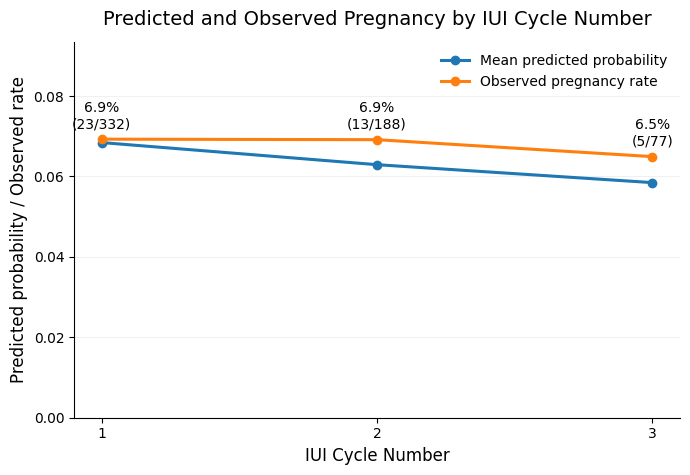


Cycle Summary:
   Cycle_Number  Total_Cycles  Actual_Pregnancies  Avg_Predicted_Prob  \
0             1           332                  23            0.068432   
1             2           188                  13            0.062930   
2             3            77                   5            0.058469   

   Observed_Pregnancy_Rate  
0                 0.069277  
1                 0.069149  
2                 0.064935  


In [60]:
# =========================
# Cycle Number Analysis
# Paper-ready version (Test - calibrated final model)
# =========================

import os
import matplotlib.pyplot as plt

os.makedirs('reports_test2/tables', exist_ok=True)
os.makedirs('reports_test2/figures/clinical', exist_ok=True)

# risk_df should come from the calibrated risk-tier block
# and Predicted_Prob should be calibrated probabilities

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Please run the calibrated risk-tier block first.")

if 'Cycle_Number' in risk_df.columns:

    cycle_summary = (
        risk_df
        .groupby('Cycle_Number')
        .agg(
            Total_Cycles=('Actual_Result', 'count'),
            Actual_Pregnancies=('Actual_Result', 'sum'),
            Avg_Predicted_Prob=('Predicted_Prob', 'mean')
        )
        .reset_index()
    )

    cycle_summary['Observed_Pregnancy_Rate'] = (
        cycle_summary['Actual_Pregnancies'] /
        cycle_summary['Total_Cycles']
    )

    cycle_summary = cycle_summary[
        cycle_summary['Cycle_Number'].isin([1, 2, 3])
    ].copy()
    cycle_summary = cycle_summary.sort_values('Cycle_Number')

    cycle_summary.to_excel(
        'reports_test2/tables/Cycle_Number_Summary.xlsx',
        index=False
    )

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Avg_Predicted_Prob'],
        marker='o',
        linewidth=2.2,
        label='Mean predicted probability'
    )

    ax.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Observed_Pregnancy_Rate'],
        marker='o',
        linewidth=2.2,
        label='Observed pregnancy rate'
    )

    for _, row in cycle_summary.iterrows():
        ax.text(
            row['Cycle_Number'],
            row['Observed_Pregnancy_Rate'] + 0.002,
            f"{row['Observed_Pregnancy_Rate']:.1%}\n"
            f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('IUI Cycle Number', fontsize=12)
    ax.set_ylabel('Predicted probability / Observed rate', fontsize=12)
    ax.set_title(
        'Predicted and Observed Pregnancy by IUI Cycle Number',
        fontsize=14, pad=12
    )

    ymax = max(
        cycle_summary['Avg_Predicted_Prob'].max(),
        cycle_summary['Observed_Pregnancy_Rate'].max()
    )
    ax.set_ylim(0, max(0.05, ymax * 1.35))

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test2/figures/clinical/Cycle_Number_Analysis_Final.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()
    plt.close()

    print("\nCycle Summary:")
    print(cycle_summary)

else:
    print("ไม่มีตัวแปร Cycle_Number ให้วิเคราะห์")


CUMULATIVE PREGNANCY SUMMARY
   Patients  Avg_Predicted_Cumulative_Prob  Observed_Pregnancy_Rate
0       353                       0.106489                 0.116147


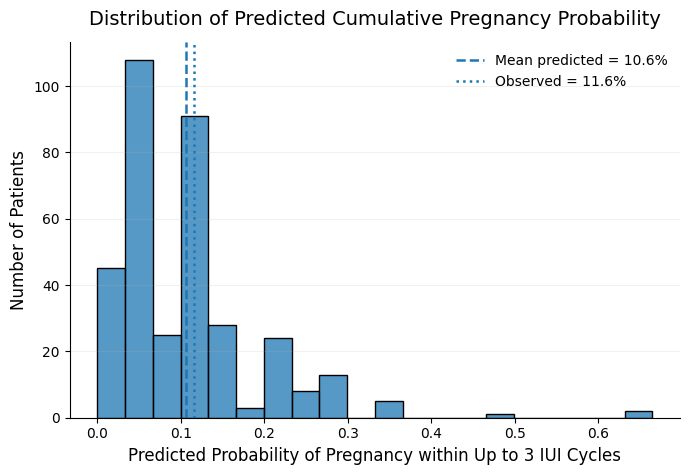

In [61]:
# ===============================
# 7. CUMULATIVE PREGNANCY ANALYSIS
# Paper-ready version (Test - calibrated final model)
# ===============================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_test2/figures/clinical', exist_ok=True)
os.makedirs('reports_test2/tables', exist_ok=True)

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Please run the calibrated risk-tier block first.")

if 'Cycle_Number' in risk_df.columns and 'HN' in risk_df.columns:

    cum_df = risk_df[risk_df['Cycle_Number'] <= 3].copy()
    cum_df = cum_df.sort_values(['HN', 'Cycle_Number'])

    cumulative_results = []

    for hn, g in cum_df.groupby('HN'):
        g = g.sort_values('Cycle_Number')

        p = g['Predicted_Prob'].values

        # Counseling-oriented approximation:
        # cumulative probability across available cycles
        cum_prob = 1 - np.prod(1 - p)

        cumulative_results.append({
            'HN': hn,
            'Num_Cycles': len(g),
            'Cumulative_Predicted_Prob': cum_prob,
            'Actual_Pregnancy': g['Actual_Result'].max()
        })

    cumulative_df = pd.DataFrame(cumulative_results)

    cumulative_df.to_excel(
        'reports_test2/tables/Cumulative_Patient_Level.xlsx',
        index=False
    )

    cumulative_summary_df = pd.DataFrame([{
        "Patients": len(cumulative_df),
        "Avg_Predicted_Cumulative_Prob": cumulative_df['Cumulative_Predicted_Prob'].mean(),
        "Observed_Pregnancy_Rate": cumulative_df['Actual_Pregnancy'].mean()
    }])

    cumulative_summary_df.to_excel(
        'reports_test2/tables/Cumulative_Summary.xlsx',
        index=False
    )

    print("\nCUMULATIVE PREGNANCY SUMMARY")
    print(cumulative_summary_df)

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    sns.histplot(
        cumulative_df['Cumulative_Predicted_Prob'],
        bins=20,
        ax=ax
    )

    mean_pred = cumulative_df['Cumulative_Predicted_Prob'].mean()
    obs_rate  = cumulative_df['Actual_Pregnancy'].mean()

    ax.axvline(
        mean_pred,
        linestyle='--',
        linewidth=1.8,
        label=f'Mean predicted = {mean_pred:.1%}'
    )

    ax.axvline(
        obs_rate,
        linestyle=':',
        linewidth=1.8,
        label=f'Observed = {obs_rate:.1%}'
    )

    ax.set_xlabel(
        'Predicted Probability of Pregnancy within Up to 3 IUI Cycles',
        fontsize=12
    )
    ax.set_ylabel('Number of Patients', fontsize=12)
    ax.set_title(
        'Distribution of Predicted Cumulative Pregnancy Probability',
        fontsize=14, pad=12
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test2/figures/clinical/Cumulative_Pregnancy_Distribution.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()
    plt.close()

else:
    print("Cycle_Number or HN not available")


Cumulative Success Summary:
   Cycle  Eligible_Patients  Observed_Cumulative_Pregnancy_Rate  \
0      1                353                            0.065156   
1      2                196                            0.102041   
2      3                 77                            0.142857   

   Model_Estimated_Cumulative_Probability  
0                                0.064361  
1                                0.111849  
2                                0.158256  


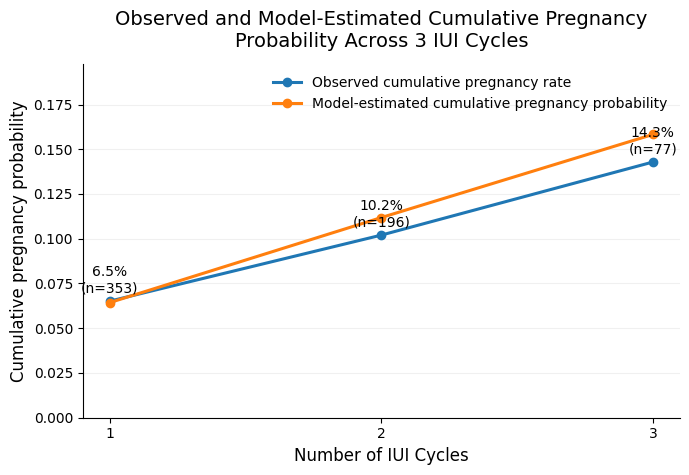

In [62]:
# =========================================
# 8. COHORT-LEVEL CUMULATIVE SUCCESS (1–3)
# Paper-ready version (Test - calibrated final model)
# =========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_test2/tables', exist_ok=True)
os.makedirs('reports_test2/figures/clinical', exist_ok=True)

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Please run the calibrated risk-tier block first.")

if 'Cycle_Number' in risk_df.columns and 'HN' in risk_df.columns:

    cum_plot_df = risk_df.copy()
    cum_plot_df = cum_plot_df[cum_plot_df['Cycle_Number'] <= 3].copy()
    cum_plot_df = cum_plot_df.sort_values(['HN', 'Cycle_Number'])

    summary_rows = []

    for k in [1, 2, 3]:
        # keep only patients with at least k observed cycles
        eligible_hn = (
            cum_plot_df.groupby('HN')['Cycle_Number']
            .max()
        )
        eligible_hn = eligible_hn[eligible_hn >= k].index

        sub = cum_plot_df[
            (cum_plot_df['HN'].isin(eligible_hn)) &
            (cum_plot_df['Cycle_Number'] <= k)
        ].copy()

        # observed cumulative pregnancy by k
        observed_by_patient = (
            sub.groupby('HN')['Actual_Result']
            .max()
            .reindex(eligible_hn, fill_value=0)
        )

        # model-estimated cumulative probability by k
        pred_by_patient = []
        for hn in eligible_hn:
            g = sub[sub['HN'] == hn].sort_values('Cycle_Number')
            p = g['Predicted_Prob'].values
            cum_prob = 1 - np.prod(1 - p)
            pred_by_patient.append(cum_prob)

        summary_rows.append({
            'Cycle': k,
            'Eligible_Patients': len(eligible_hn),
            'Observed_Cumulative_Pregnancy_Rate': observed_by_patient.mean(),
            'Model_Estimated_Cumulative_Probability': float(np.mean(pred_by_patient))
        })

    cumulative_summary_df = pd.DataFrame(summary_rows)

    cumulative_summary_df.to_excel(
        'reports_test2/tables/Cumulative_Success_By_Cycle.xlsx',
        index=False
    )

    print("\nCumulative Success Summary:")
    print(cumulative_summary_df)

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'],
        marker='o',
        linewidth=2.2,
        label='Observed cumulative pregnancy rate'
    )

    ax.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'],
        marker='o',
        linewidth=2.2,
        label='Model-estimated cumulative pregnancy probability'
    )

    for _, row in cumulative_summary_df.iterrows():
        ax.text(
            row['Cycle'],
            row['Observed_Cumulative_Pregnancy_Rate'] + 0.005,
            f"{row['Observed_Cumulative_Pregnancy_Rate']:.1%}\n"
            f"(n={int(row['Eligible_Patients'])})",
            ha='center',
            fontsize=10
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Number of IUI Cycles', fontsize=12)
    ax.set_ylabel('Cumulative pregnancy probability', fontsize=12)
    ax.set_title(
        'Observed and Model-Estimated Cumulative Pregnancy\nProbability Across 3 IUI Cycles',
        fontsize=14, pad=12
    )

    ymax = max(
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'].max(),
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'].max()
    )
    ax.set_ylim(0, max(0.05, ymax * 1.25))

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test2/figures/clinical/Cumulative_Success_By_Cycle.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()
    plt.close()

else:
    print("ต้องมีทั้ง HN และ Cycle_Number เพื่อคำนวณ cumulative success")


CUMULATIVE BY BASELINE RISK TIER (FIXED COHORT)
                  Baseline_Risk_Tier  Cycle  Patients_in_Tier  \
0           Tier 1 (Low Probability)      1                85   
1           Tier 1 (Low Probability)      2                85   
2           Tier 1 (Low Probability)      3                85   
3  Tier 2 (Intermediate Probability)      1               157   
4  Tier 2 (Intermediate Probability)      2               157   
5  Tier 2 (Intermediate Probability)      3               157   
6          Tier 3 (High Probability)      1                90   
7          Tier 3 (High Probability)      2                90   
8          Tier 3 (High Probability)      3                90   

   Observed_Cumulative_Pregnancy_Rate  Pregnancies_by_Cycle_k  
0                            0.023529                       2  
1                            0.047059                       4  
2                            0.070588                       6  
3                            0.038217       

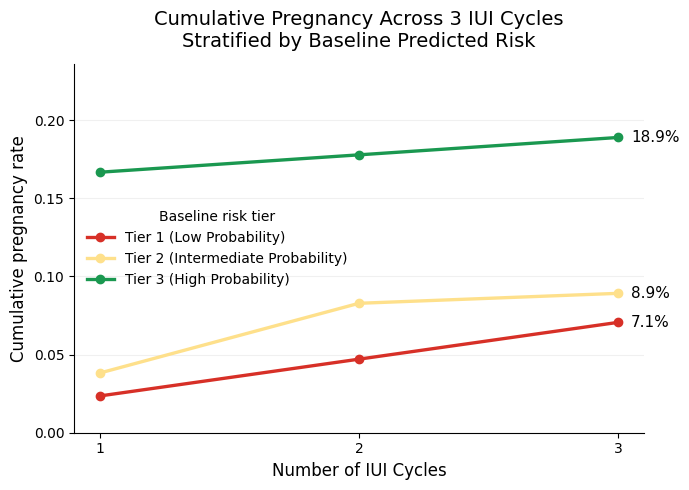

In [64]:
# ==========================================
# 9. CUMULATIVE PREGNANCY BY BASELINE RISK TIER (FIXED COHORT)
# Paper-ready FINAL version
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_test2/tables', exist_ok=True)
os.makedirs('reports_test2/figures/clinical', exist_ok=True)

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Run calibrated model block first.")

if 'HN' in risk_df.columns and 'Cycle_Number' in risk_df.columns:

    tier_order = [
        'Tier 1 (Low Probability)',
        'Tier 2 (Intermediate Probability)',
        'Tier 3 (High Probability)'
    ]

    if 'c1' not in globals() or 'c2' not in globals():
        raise ValueError("c1/c2 not found. Run risk-tier block first.")

    df = risk_df.copy()
    df = df[df['Cycle_Number'] <= 3].copy()
    df = df.sort_values(['HN', 'Cycle_Number'])

    # --------------------------------
    # 1) DEFINE BASELINE TIER (cycle 1)
    # --------------------------------
    baseline = df[df['Cycle_Number'] == 1].copy()

    baseline['Baseline_Risk_Tier'] = pd.cut(
        baseline['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_order,
        include_lowest=True
    )

    baseline_map = baseline[['HN', 'Baseline_Risk_Tier']].drop_duplicates()

    df = df.merge(baseline_map, on='HN', how='inner')

    # --------------------------------
    # 2) CUMULATIVE (FIXED COHORT)
    # --------------------------------
    rows = []

    for tier in tier_order:

        sub = df[df['Baseline_Risk_Tier'] == tier].copy()

        if sub.empty:
            continue

        patient_ids = sub['HN'].unique()

        for k in [1, 2, 3]:

            sub_k = sub[sub['Cycle_Number'] <= k].copy()

            preg_by_patient = (
                sub_k.groupby('HN')['Actual_Result']
                .max()
                .reindex(patient_ids, fill_value=0)
            )

            rows.append({
                'Baseline_Risk_Tier': tier,
                'Cycle': k,
                'Patients_in_Tier': len(patient_ids),
                'Observed_Cumulative_Pregnancy_Rate': preg_by_patient.mean(),
                'Pregnancies_by_Cycle_k': int(preg_by_patient.sum())
            })

    result_df = pd.DataFrame(rows)

    result_df.to_excel(
        'reports_test2/tables/Cumulative_Pregnancy_By_Baseline_Risk_Tier_FIXED.xlsx',
        index=False
    )

    print("\nCUMULATIVE BY BASELINE RISK TIER (FIXED COHORT)")
    print(result_df)

    # --------------------------------
    # 3) PLOT
    # --------------------------------
    tier_color_map = {
        'Tier 1 (Low Probability)': '#d73027',
        'Tier 2 (Intermediate Probability)': '#fee08b',
        'Tier 3 (High Probability)': '#1a9850'
    }

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    for tier in tier_order:

        sub = result_df[result_df['Baseline_Risk_Tier'] == tier]

        if sub.empty:
            continue

        ax.plot(
            sub['Cycle'],
            sub['Observed_Cumulative_Pregnancy_Rate'],
            marker='o',
            linewidth=2.4,
            label=tier,
            color=tier_color_map[tier]
        )

        last = sub.sort_values('Cycle').iloc[-1]

        ax.text(
            last['Cycle'] + 0.05,
            last['Observed_Cumulative_Pregnancy_Rate'],
            f"{last['Observed_Cumulative_Pregnancy_Rate']:.1%}",
            fontsize=11,
            va='center'
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Number of IUI Cycles', fontsize=12)
    ax.set_ylabel('Cumulative pregnancy rate', fontsize=12)

    ax.set_title(
        'Cumulative Pregnancy Across 3 IUI Cycles\nStratified by Baseline Predicted Risk',
        fontsize=14,
        pad=12
    )

    ymax = result_df['Observed_Cumulative_Pregnancy_Rate'].max()
    ax.set_ylim(0, ymax * 1.25)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(title='Baseline risk tier', frameon=False)

    plt.tight_layout()

    plt.savefig(
        'reports_test2/figures/clinical/Cumulative_Pregnancy_By_Baseline_Risk_Tier_FIXED.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()
    plt.close()

else:
    print("ต้องมี HN และ Cycle_Number")

### 7. Decision Curve Analysis (DCA)

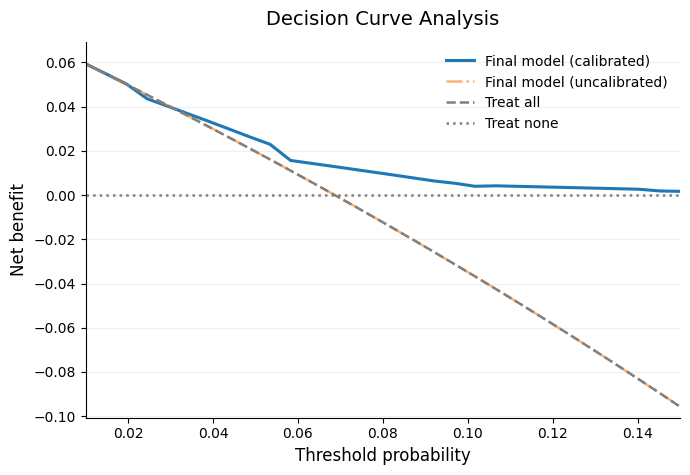


✅ DCA complete for final model
Saved:
- reports_test2/tables/DCA_Analysis_Final_Model.xlsx
- reports_test2/figures/dca/DCA_Final_Model.png


In [65]:
# =========================
# 10. Decision Curve Analysis
# Final calibrated model version
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_test2/tables', exist_ok=True)
os.makedirs('reports_test2/figures/dca', exist_ok=True)

# clinically relevant threshold range
thresholds = np.linspace(0.01, 0.15, 30)

# require calibrated model outputs
required_objects = ['y_test', 'test_probs_raw', 'test_probs_calibrated']
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Run the group-aware calibration block first.")

# -----------------------------
# Net benefit calculations
# -----------------------------
nb_model_raw = [
    calculate_net_benefit(y_test, test_probs_raw, t)
    for t in thresholds
]

nb_model_cal = [
    calculate_net_benefit(y_test, test_probs_calibrated, t)
    for t in thresholds
]

nb_all = [
    calculate_net_benefit(y_test, np.ones(len(y_test)), t)
    for t in thresholds
]

nb_none = [0.0] * len(thresholds)

# save table
dca_df = pd.DataFrame({
    'Threshold': thresholds,
    'Net_Benefit_Raw': nb_model_raw,
    'Net_Benefit_Calibrated': nb_model_cal,
    'Treat_All': nb_all,
    'Treat_None': nb_none
})

dca_df.to_excel(
    'reports_test2/tables/DCA_Analysis_Final_Model.xlsx',
    index=False
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

ax.plot(
    thresholds, nb_model_cal,
    linewidth=2.2,
    label='Final model (calibrated)'
)

ax.plot(
    thresholds, nb_model_raw,
    linewidth=1.8,
    linestyle='-.',
    alpha=0.6,
    label='Final model (uncalibrated)'
)

ax.plot(
    thresholds, nb_all,
    color='gray',
    linestyle='--',
    linewidth=1.8,
    label='Treat all'
)

ax.plot(
    thresholds, nb_none,
    color='gray',
    linestyle=':',
    linewidth=1.8,
    label='Treat none'
)

ax.set_xlabel('Threshold probability', fontsize=12)
ax.set_ylabel('Net benefit', fontsize=12)
ax.set_title('Decision Curve Analysis', fontsize=14, pad=12)

ax.set_xlim(0.01, 0.15)

ymin = min(
    np.nanmin(nb_model_raw),
    np.nanmin(nb_model_cal),
    np.nanmin(nb_all),
    0
)
ymax = max(
    np.nanmax(nb_model_raw),
    np.nanmax(nb_model_cal),
    np.nanmax(nb_all),
    0
)
ax.set_ylim(ymin - 0.005, ymax + 0.01)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    'reports_test2/figures/dca/DCA_Final_Model.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("\n✅ DCA complete for final model")
print("Saved:")
print("- reports_test2/tables/DCA_Analysis_Final_Model.xlsx")
print("- reports_test2/figures/dca/DCA_Final_Model.png")